# Comparaison des Scores de Risque FARS

Ce notebook compare les fichiers `risk_scores.csv` générés par différentes configurations du système FARS. 
L'objectif est d'analyser l'impact des différentes configurations sur :
1.  Le score de risque et l'incertitude (Global & vs Baseline)
2.  Les métriques des modèles sous-jacents (F1, Corrélation)
3.  La performance par rapport aux données réelles (Ground Truth)
4.  La comparaison directe entre la capacité prédictive du FARS et celle de l'indice DFE.

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import glob
import os
import numpy as np
import json
import re

# Configuration
BASE_DIR = "FARS_ZONE_METEO_06/FARS_ARTICLE"
BASELINE_CONFIG = "Bulletin"  # Nom du dossier de référence

# Style des plots
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)

In [8]:

import datetime as dt
import numpy as np

def find_dates_between(start, end):
    start_date = dt.datetime.strptime(start, '%Y-%m-%d').date()
    end_date = dt.datetime.strptime(end, '%Y-%m-%d').date()

    delta = dt.timedelta(days=1)
    date = start_date
    res = []
    while date < end_date:
            res.append(date.strftime("%Y-%m-%d"))
            date += delta
    return res

def graph_id2_num_zone(df):
    dico = {}
    if 'departement' in df.columns:
         graph_ids = np.sort(np.unique(df[df['departement'] == 6]['graph_id']))
         num_zone = [65,62,64,61,66,67,63]
         for i, gi in enumerate(graph_ids):
             if i < len(num_zone):
                dico[gi] = num_zone[i]
    
    if 'graph_id' in df.columns:
        graph_ids_all = np.unique(df['graph_id'])
        for gi in graph_ids_all:
            if gi not in dico:
                dico[gi] = gi

    df['num_zone'] = df['graph_id'].map(dico)
    return df


## 1. Chargement des Données (Risk Scores)

In [9]:
import pickle

scale = "3"
graph_construct = None
horizon_train = '0'
kdays = '10'
under_sampling = "full"
clustering = "quantile"
expe = "default"

clustering_suffix = f'{clustering}-5-Class-Dept'

TARGET_COLUMNS = {
    'nbsinister': f'nbsinister-{clustering_suffix}',
    'timeintervention': f'timeintervention-{clustering_suffix}',
    'DFE': 'DFE',
    'ressource': f'ressource-{clustering_suffix}',
}

def _run_and_save_predictions(model, resolved_target: str):
    """
    Runs multi-horizon predictions and saves results in model.df_test.
    Follows logic from GNN.dataloader.test_dl_model.
    """
    from GNN.dataloader import filter_prediction
    from GNN.config import date_index, graph_id_index, scale_index, weight_index
    
    df_test = model.df_test
    target_col = TARGET_COLUMNS.get(resolved_target, resolved_target)
    
    # Run predictions with return_y=True for alignment
    pred_tensor, y_tensor = model.predict(df_test, return_y=True)
    
    # Run probabilities
    try:
        pred_proba_tensor, _ = model.predict_proba(df_test, return_y=True)
    except Exception:
        pred_proba_tensor = None

    # Convert to numpy
    if hasattr(y_tensor, 'detach'):
        y_tensor = y_tensor.detach().cpu().numpy()
    if hasattr(pred_tensor, 'detach'):
        pred_tensor = pred_tensor.detach().cpu().numpy()
    if pred_proba_tensor is not None and hasattr(pred_proba_tensor, 'detach'):
        pred_proba_tensor = pred_proba_tensor.detach().cpu().numpy()

    # Mock graphScale for filter_prediction
    class MockGS:
        def __init__(self):
            self.graph_method = graph_construct
            self.base = scale
            self.scale = scale

    # Align predictions
    pred_all, y_all, df_filtered = filter_prediction(MockGS(), df_test, pred_tensor, y_tensor, None, None)
    
    if pred_proba_tensor is not None:
        pred_proba_all, _, _ = filter_prediction(MockGS(), df_test, pred_proba_tensor, y_tensor, None, None)
    else:
        pred_proba_all = None

    horizon = model.horizon if hasattr(model, "horizon") else 0
    
    # Add columns for each horizon
    for H in range(horizon + 1):
        idx = -1 - (horizon - H)
        
        col_base = f"prediction_{target_col}_{H}"
        df_filtered[col_base] = pred_all[:, idx]
        
        if pred_proba_all is not None:
            for c in range(pred_proba_all.shape[-1]):
                df_filtered[f"{col_base}_C{c}"] = pred_proba_all[:, idx, c]

    return df_filtered, model.df_train

fire_df, train_fire_df = _run_and_save_predictions(pickle.load(open('GNN/occurence_default/check_z-score/full_all_3_0_risk-size-zonemeteo-degree-a3-r5-t0.3_node/GRU_full_full_10_0_all_one_nbsinister-quantile-5-Class-Dept_classification_flwki-id{departement}/GRU_full_full_10_0_all_one_nbsinister-quantile-5-Class-Dept_classification_flwki-id{departement}.pkl', 'rb')), 'nbsinister')
res_df, train_res_df = _run_and_save_predictions(pickle.load(open('GNN/occurence_default/check_z-score/full_all_3_0_risk-size-zonemeteo-degree-a3-r5-t0.3_node/GRU_full_full_10_0_all_one_ressource-quantile-5-Class-Dept_classification_flwki-id{departement}/GRU_full_full_10_0_all_one_ressource-quantile-5-Class-Dept_classification_flwki-id{departement}.pkl', 'rb')), 'ressource')
time_df, train_time_df = _run_and_save_predictions(pickle.load(open('GNN/occurence_default/check_z-score/full_all_3_0_risk-size-zonemeteo-degree-a3-r5-t0.3_node/GRU_full_full_10_0_all_one_timeintervention-quantile-5-Class-Dept_classification_flwki-id{departement}/GRU_full_full_10_0_all_one_timeintervention-quantile-5-Class-Dept_classification_flwki-id{departement}.pkl', 'rb')), 'timeintervention')
dfe_df, _ = _run_and_save_predictions(pickle.load(open('GNN/occurence_default/check_z-score/full_all_3_0_risk-size-zonemeteo-degree-a3-r5-t0.3_node/GRU_full_full_10_10_all_one_DFE_classification_wkloss/GRU_full_full_10_10_all_one_DFE_classification_wkloss.pkl', 'rb')), 'DFE')

/tmp/ipykernel_534709/3249927553.py:78: DeprecationWarning: numpy.core.numeric is deprecated and has been renamed to numpy._core.numeric. The numpy._core namespace contains private NumPy internals and its use is discouraged, as NumPy internals can change without warning in any release. In practice, most real-world usage of numpy.core is to access functionality in the public NumPy API. If that is the case, use the public NumPy API. If not, you are using NumPy internals. If you would still like to access an internal attribute, use numpy._core.numeric._frombuffer.
  fire_df, train_fire_df = _run_and_save_predictions(pickle.load(open('GNN/occurence_default/check_z-score/full_all_3_0_risk-size-zonemeteo-degree-a3-r5-t0.3_node/GRU_full_full_10_0_all_one_nbsinister-quantile-5-Class-Dept_classification_flwki-id{departement}/GRU_full_full_10_0_all_one_nbsinister-quantile-5-Class-Dept_classification_flwki-id{departement}.pkl', 'rb')), 'nbsinister')
/home/caron/Bureau/predictops-mcp/GNN/tools.py:

In [10]:
train_time_df.departement.unique()

array([78,  6, 25,  1, 69])

<Axes: >

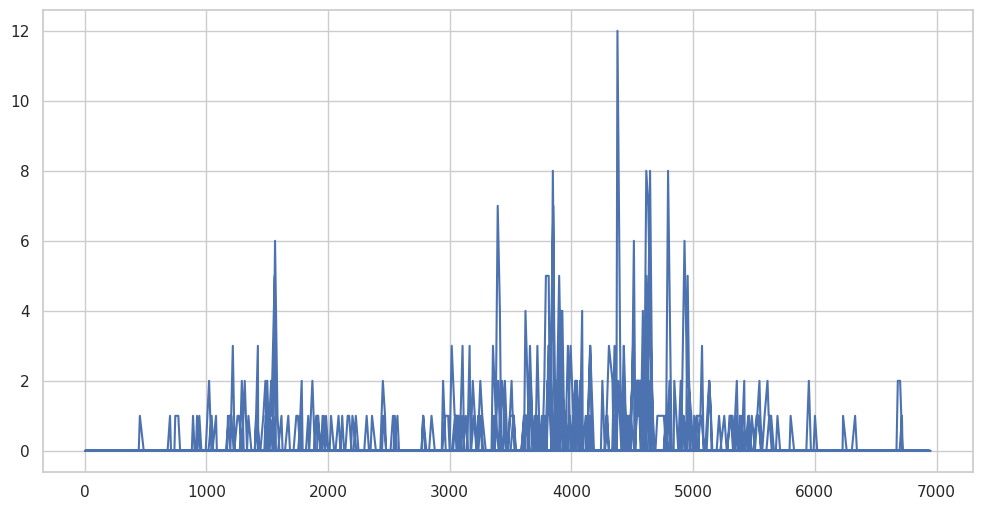

In [11]:
time_df[(time_df['departement'] == 1)]['ressource'].plot()

In [12]:
dfe_df

,date,reseau,validite,departement,num_zone,T,U,DD,FF,RR,...,prediction_DFE_9_C1,prediction_DFE_9_C2,prediction_DFE_9_C3,prediction_DFE_9_C4,prediction_DFE_10,prediction_DFE_10_C0,prediction_DFE_10_C1,prediction_DFE_10_C2,prediction_DFE_10_C3,prediction_DFE_10_C4
0,3088,AM,J,6,61.0,27.0,44.0,17.0,14.8,3.0,...,0.999297,6.970887e-04,1.910431e-06,2.141917e-06,1,1.517893e-09,1.000000,3.395821e-08,4.889510e-10,6.551754e-10
7,3089,AM,J,6,61.0,27.0,65.0,10.0,18.5,0.0,...,1.000000,5.639509e-08,1.045682e-09,1.381140e-09,1,4.014651e-10,1.000000,9.754309e-09,2.465969e-10,2.243116e-10
14,3090,AM,J,6,61.0,26.0,60.0,13.0,9.3,0.0,...,1.000000,1.455352e-08,3.118460e-10,2.981331e-10,1,9.823994e-08,1.000000,9.396744e-09,1.873118e-09,3.014651e-09
21,3091,AM,J,6,61.0,27.0,60.0,10.0,18.5,0.0,...,1.000000,6.800078e-09,1.543588e-09,2.297875e-09,1,2.854391e-08,1.000000,4.343353e-08,4.072737e-09,3.305880e-09
28,3092,AM,J,6,61.0,28.0,38.0,9.0,22.2,0.0,...,1.000000,4.922725e-08,5.280747e-09,4.276405e-09,1,3.030587e-09,1.000000,3.312097e-09,6.328462e-10,3.087083e-10
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
673,3184,AM,J,6,67.0,18.0,75.0,12.0,14.8,0.0,...,0.999998,1.276002e-09,6.711899e-10,1.092039e-09,1,3.192695e-06,0.999997,2.931672e-09,1.139672e-09,2.086601e-09
680,3185,AM,J,6,67.0,17.0,86.0,22.0,9.3,21.0,...,0.999995,4.815051e-09,1.959074e-09,3.376696e-09,1,1.784364e-05,0.999982,9.818457e-09,3.637728e-09,7.357866e-09
687,3186,AM,J,6,67.0,20.0,57.0,30.0,14.8,9.0,...,0.999978,1.177265e-08,4.966924e-09,9.480575e-09,1,5.432659e-04,0.999457,3.859605e-08,1.961901e-08,4.747722e-08
694,3187,AM,J,6,67.0,17.0,50.0,22.0,14.8,0.0,...,0.999342,4.262733e-08,2.321997e-08,5.625509e-08,1,9.280576e-03,0.990719,8.096232e-08,6.163943e-08,1.614061e-07


In [13]:
import pickle
import os
import pandas as pd
from stastisc_model import StatModel, MaxWeekModel, PoissonModel, PersistenceModel, LogisticRegressionModel, graph_id2_num_zone, find_dates_between

# Définition des modèles et targets
stat_models_names = ["LogisticRegression", "Persistence", "MaxWeek", "Poisson"]
name_mapping = {
    "LogisticRegression": "LR",
    "Persistence": "Persistence",
    "MaxWeek": "MaxWeek",
    "Poisson": "Poisson"
}
targets_map = {
    "nbsinister": "nbsinister-quantile-5-Class-Dept",
    "ressource": "ressource-quantile-5-Class-Dept",
    "timeintervention": "timeintervention-quantile-5-Class-Dept"
}

# Dictionnaire pour stocker les résultats
# Structure : stats_results[model_name][target_name] = dataframe
stats_results = {m: {} for m in stat_models_names}

for target_name, target_col in targets_map.items():
    for model_name in stat_models_names:
        filename = f"STATS_MODELS/{target_name}_{model_name}.pkl"
        
        if os.path.exists(filename):
            print(f"Chargement de {filename}...")
            with open(filename, "rb") as f:
                model = pickle.load(f)
            
            df_test = model.df_test
            if 'num_zone' not in df_test.columns.unique():
                df_test = graph_id2_num_zone(df_test)
                
            # Générer les prédictions
            preds = model.predict(df_test)
            
            # Créer le DataFrame de résultat
            df_res = model.df_test.copy()
            
            # Ajouter la colonne de prédiction
            pred_col_name = f"prediction_{target_col}_0"
            df_res[pred_col_name] = preds
            
            # Stocker le résultat
            stats_results[model_name][target_name] = df_res
        else:
            print(f"Attention : {filename} introuvable.")

/home/caron/Bureau/predictops-mcp/GNN/tools.py:866: RuntimeWarning: overflow encountered in cast
  cur_array = cur_array.astype(np.float32)
/home/caron/Bureau/predictops-mcp/GNN/tools.py:866: RuntimeWarning: overflow encountered in cast
  cur_array = cur_array.astype(np.float32)
/home/caron/Bureau/predictops-mcp/GNN/tools.py:866: RuntimeWarning: overflow encountered in cast
  cur_array = cur_array.astype(np.float32)
/home/caron/Bureau/predictops-mcp/GNN/tools.py:866: RuntimeWarning: overflow encountered in cast
  cur_array = cur_array.astype(np.float32)


Datasets loaded successfully.
Merged shape: (702, 13)
Chargement de STATS_MODELS/nbsinister_LogisticRegression.pkl...
Chargement de STATS_MODELS/nbsinister_Persistence.pkl...
Chargement de STATS_MODELS/nbsinister_MaxWeek.pkl...
Chargement de STATS_MODELS/nbsinister_Poisson.pkl...
Chargement de STATS_MODELS/ressource_LogisticRegression.pkl...
Chargement de STATS_MODELS/ressource_Persistence.pkl...
Chargement de STATS_MODELS/ressource_MaxWeek.pkl...
Chargement de STATS_MODELS/ressource_Poisson.pkl...
Chargement de STATS_MODELS/timeintervention_LogisticRegression.pkl...
Chargement de STATS_MODELS/timeintervention_Persistence.pkl...
Chargement de STATS_MODELS/timeintervention_MaxWeek.pkl...
Chargement de STATS_MODELS/timeintervention_Poisson.pkl...


In [14]:
######## A APPLIQUER A TOUT LES DATAFRAMES CHARGE (GRU + STATS_MODELS) ##########

fire_df = fire_df[fire_df['departement'] == 6]
res_df = res_df[res_df['departement'] == 6]
time_df = time_df[time_df['departement'] == 6]

# Filter Stats Models
for model_name in stat_models_names:
    for target_name, df in stats_results[model_name].items():
        if df is not None and 'departement' in df.columns:
            stats_results[model_name][target_name] = df[df['departement'] == 6].copy()


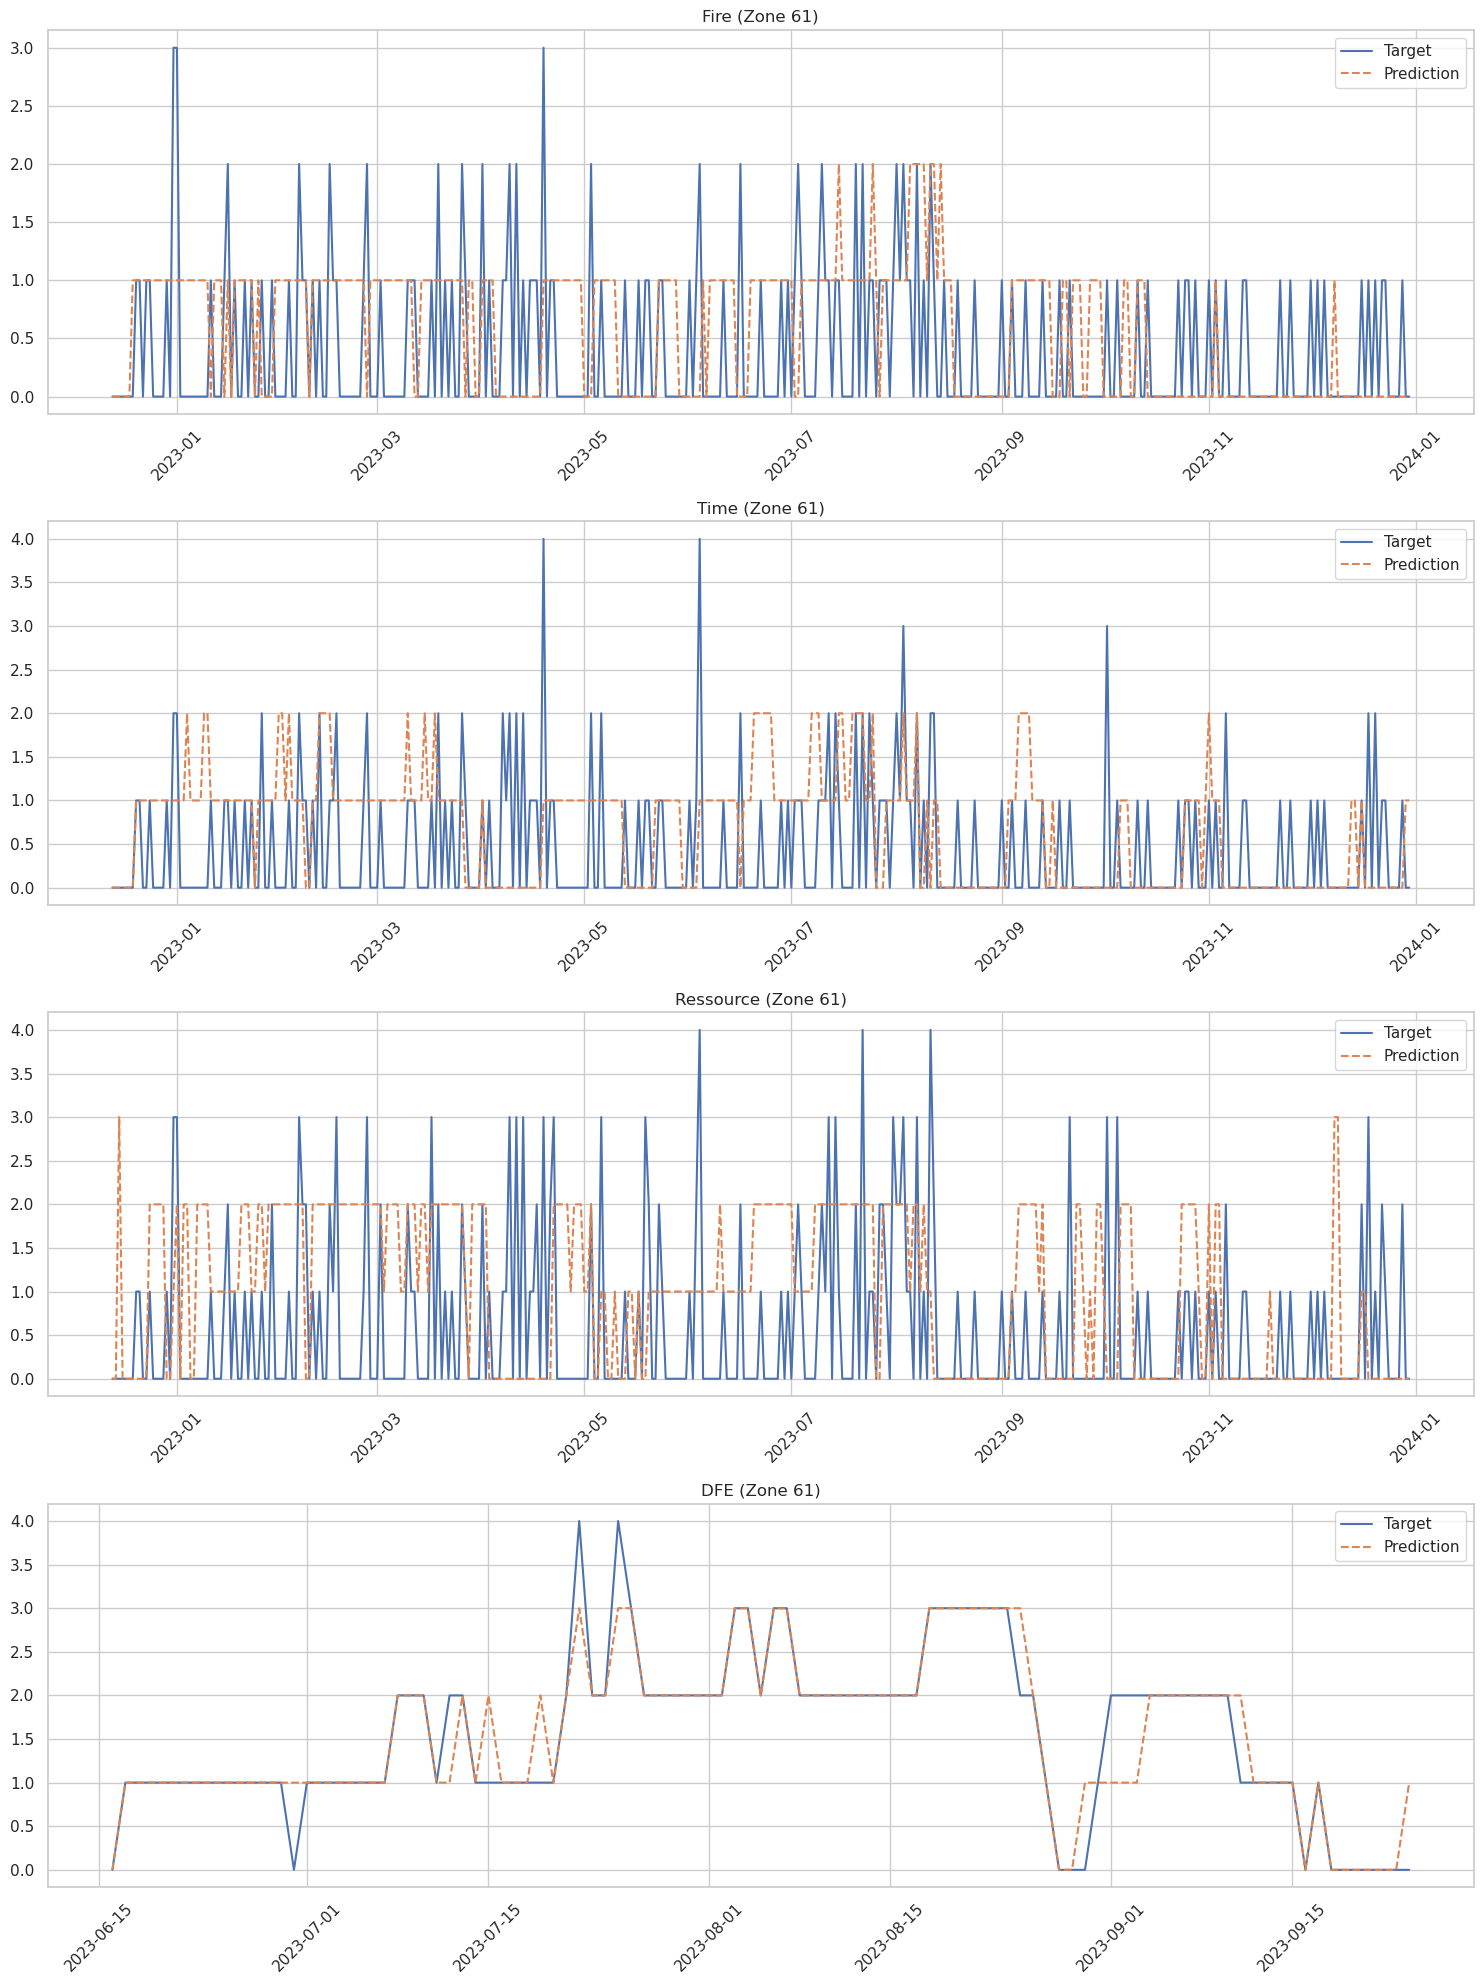

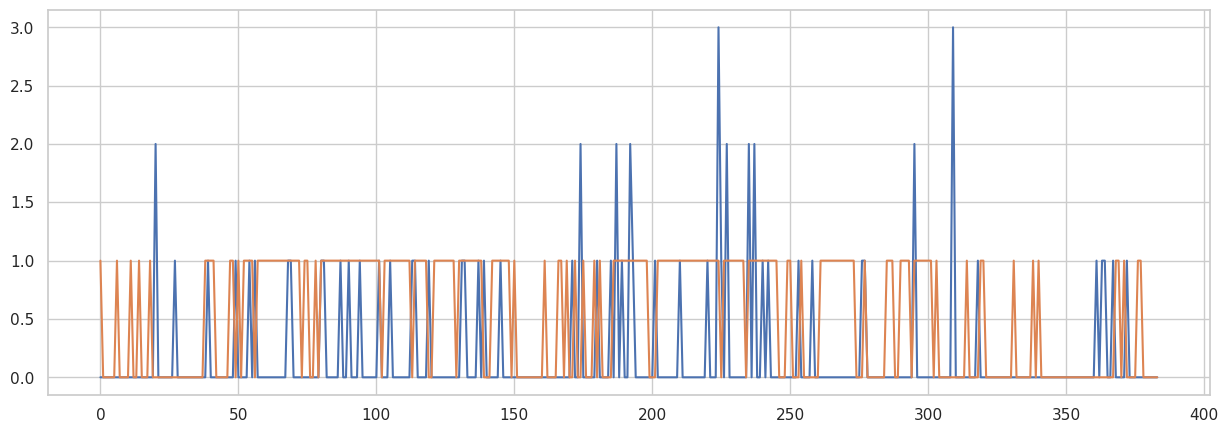

In [15]:
%matplotlib inline

rit = stats_results['LogisticRegression']['nbsinister']
col = f'nbsinister-{clustering}-5-Class-Dept'

nz = 62

rit = rit[rit['num_zone'] == 62]

plt.figure(figsize=(15,5))
plt.plot(rit[col].values)
plt.plot(rit[f'prediction_{col}_0'].values)
plt.show()

In [16]:
######## A APPLIQUER A TOUT LES DATAFRAMES CHARGE (GRU + STATS_MODELS) ##########

# Process Dates for DFE
allDates_dfe = find_dates_between('2015-01-01', '2024-12-31')
dfe_df['date'] = dfe_df['date'].apply(lambda x : allDates_dfe[x] if x < len(allDates_dfe) else None)
dfe_df['date'] = pd.to_datetime(dfe_df['date'])
dfe_df['num_zone'] = dfe_df['graph_id']

# Process Dates for Fire/Time/Res
allDates_fire = find_dates_between('2017-06-12', '2024-12-31')

for df in [fire_df, time_df, res_df]:
    df['date'] = df['date'].apply(lambda x : allDates_fire[x] if x < len(allDates_fire) else None)
    df['date'] = pd.to_datetime(df['date'])
    df = graph_id2_num_zone(df)

# Process Dates for Stats Models
for model_name in stat_models_names:
    for target_name, df in stats_results[model_name].items():
        if df is not None:
            # Assuming df_test from stastisc_model already has correct dates or needs same processing
            # If they come from the same source as GRU, they might need the same processing.
            # Let's apply it to be safe, or check if 'date' is already datetime.
            # But wait, stastisc_model.py uses find_dates_between too.
            # Let's apply the same logic.
            if df['date'].dtype == 'O' or df['date'].dtype == 'int64': # If not datetime
                 # Try to apply mapping if it looks like index
                 # But we need to be careful. Let's assume they need it if they are raw.
                 try:
                     df['date'] = df['date'].apply(lambda x : allDates_fire[x] if isinstance(x, int) and x < len(allDates_fire) else x)
                 except:
                     pass
            
            df['date'] = pd.to_datetime(df['date'])
            df = graph_id2_num_zone(df)
            stats_results[model_name][target_name] = df

print("Ground Truth and Stats Models Data Loaded Successfully.")


Ground Truth and Stats Models Data Loaded Successfully.


In [17]:
data_frames = {}
search_path = os.path.join(BASE_DIR, "*", "risk_scores.csv")

for file_path in glob.glob(search_path):
    config_name = os.path.basename(os.path.dirname(file_path))
    try:
        df = pd.read_csv(file_path)
        # Conversion des types si nécessaire
        df['risk_score'] = pd.to_numeric(df['risk_score'], errors='coerce')
        df['uncertainty_value'] = pd.to_numeric(df['uncertainty_value'], errors='coerce')
        df['config'] = config_name
        df = df[df['run'] == 0]
        
        df.dropna(subset='risk_score', inplace=True)
        
        print(config_name, len(df))
        if len(df) < 360:
            continue  # Ignorer les petits fichiers
        data_frames[config_name] = df
        print(f"Chargé : {config_name} ({len(df)} lignes)")
    except Exception as e:
        print(f"Erreur lors du chargement de {config_name}: {e}")

if not data_frames:
    print("Aucun fichier de données trouvé !")
else:
    # Concaténer tout pour une analyse globale
    all_data = pd.concat(data_frames.values(), ignore_index=True)
    
    # Group/Sort by run instead of filtering
    all_data = all_data.sort_values(by=['run', 'config'])

Bulletin_Skip_Feature_Without_Nbsinister 537
Chargé : Bulletin_Skip_Feature_Without_Nbsinister (537 lignes)
Bulletin_Skip_Feature_Without_Nbsinister_Time 539
Chargé : Bulletin_Skip_Feature_Without_Nbsinister_Time (539 lignes)
Bulletin_Skip_Feature_No_Time_Res 538
Chargé : Bulletin_Skip_Feature_No_Time_Res (538 lignes)
Bulletin_All_Targets_No_Agents 539
Chargé : Bulletin_All_Targets_No_Agents (539 lignes)
Bulletin_Skip_Feature_Without_Nbsinister_Time_Ressource 537
Chargé : Bulletin_Skip_Feature_Without_Nbsinister_Time_Ressource (537 lignes)
Bulletin_Skip_Feature_Without_time 539
Chargé : Bulletin_Skip_Feature_Without_time (539 lignes)
Bulletin_Skip_Feature_Without_DFE 536
Chargé : Bulletin_Skip_Feature_Without_DFE (536 lignes)
Bulletin_All_Targets_Skip_Feature 539
Chargé : Bulletin_All_Targets_Skip_Feature (539 lignes)
Bulletin_Skip_Feature_Without_ressource 537
Chargé : Bulletin_Skip_Feature_Without_ressource (537 lignes)


In [18]:
for key in data_frames:
    if np.any(data_frames[key]['risk_level'].unique()) not in ['Faible', 'Nul', 'Moyen', 'Élevé', 'Extrême', 'Extrême']:
        bad_index = data_frames[key][~data_frames[key]['risk_level'].isin(['Faible', 'Nul', 'Moyen', 'Élevé', 'Extreme', 'Extrême'])].date
        print(f"Configuration '{key}' contient des niveaux de risque inattendus aux dates : {bad_index.tolist()}")

Configuration 'Bulletin_Skip_Feature_Without_Nbsinister' contient des niveaux de risque inattendus aux dates : []
Configuration 'Bulletin_Skip_Feature_Without_Nbsinister_Time' contient des niveaux de risque inattendus aux dates : []
Configuration 'Bulletin_Skip_Feature_No_Time_Res' contient des niveaux de risque inattendus aux dates : []
Configuration 'Bulletin_All_Targets_No_Agents' contient des niveaux de risque inattendus aux dates : []
Configuration 'Bulletin_Skip_Feature_Without_Nbsinister_Time_Ressource' contient des niveaux de risque inattendus aux dates : ['2023-09-25', '2023-09-25', '2023-09-25', '2023-09-25', '2023-09-25', '2023-09-25', '2023-09-25']
Configuration 'Bulletin_Skip_Feature_Without_time' contient des niveaux de risque inattendus aux dates : ['2023-08-02']
Configuration 'Bulletin_Skip_Feature_Without_DFE' contient des niveaux de risque inattendus aux dates : []
Configuration 'Bulletin_All_Targets_Skip_Feature' contient des niveaux de risque inattendus aux dates : 

In [19]:
all_data['uncertainty_value'] = all_data['uncertainty_value'].clip(lower=0)

## 2. Analyse Statistique Globale (Risk Scores)

Comparaison des distributions de `risk_score` et `uncertainty_value` par configuration.

risk_score         \
                                                         mean median   
config                                                                 
Bulletin_All_Targets_No_Agents                       1.513915    1.0   
Bulletin_All_Targets_Skip_Feature                    1.461967    1.0   
Bulletin_Skip_Feature_No_Time_Res                    1.377323    1.0   
Bulletin_Skip_Feature_Without_DFE                    0.671642    0.0   
Bulletin_Skip_Feature_Without_Nbsinister             1.575419    2.0   
Bulletin_Skip_Feature_Without_Nbsinister_Time        1.562152    2.0   
Bulletin_Skip_Feature_Without_Nbsinister_Time_R...   1.627561    2.0   
Bulletin_Skip_Feature_Without_ressource              1.480447    1.0   
Bulletin_Skip_Feature_Without_time                   1.612245    2.0   

                                                                            \
                                                         std min max count   
config                                                                       
Bulletin_All_Targets_No_Agents                      0.947159   0   4   539   
Bulletin_All_Targets_Skip_Feature                   0.946496   0   4   539   
Bulletin_Skip_Feature_No_Time_Res                   1.006870   0   4   538   
Bulletin_Skip_Feature_Without_DFE                   0.822816   0   4   536   
Bulletin_Skip_Feature_Without_Nbsinister            0.929608   0   4   537   
Bulletin_Skip_Feature_Without_Nbsinister_Time       0.913211   0   4   539   
Bulletin_Skip_Feature_Without_Nbsinister_Time_R...  0.947810   0   4   537   
Bulletin_Skip_Feature_Without_ressource             0.946365   0   4   537   
Bulletin_Skip_Feature_Without_time                  0.806524   0   3   539   

                                                   uncertainty_value         \
                                                                mean median   
config                                                                        
Bulletin_All_Targets_No_Agents                              0.011101    0.0   
Bulletin_All_Targets_Skip_Feature                           0.006865    0.0   
Bulletin_Skip_Feature_No_Time_Res                           0.008831    0.0   
Bulletin_Skip_Feature_Without_DFE                           0.020993    0.0   
Bulletin_Skip_Feature_Without_Nbsinister                    0.008284    0.0   
Bulletin_Skip_Feature_Without_Nbsinister_Time               0.012603    0.0   
Bulletin_Skip_Feature_Without_Nbsinister_Time_R...          0.010627    0.0   
Bulletin_Skip_Feature_Without_ressource                     0.001729    0.0   
Bulletin_Skip_Feature_Without_time                          0.005214    0.0   

                                                                               
                                                         std  min   max count  
config                                                                         
Bulletin_All_Targets_No_Agents                      0.056757  0.0  0.55   539  
Bulletin_All_Targets_Skip_Feature                   0.040767  0.0  0.45   539  
Bulletin_Skip_Feature_No_Time_Res                   0.048753  0.0  0.48   538  
Bulletin_Skip_Feature_Without_DFE                   0.081219  0.0  0.55   536  
Bulletin_Skip_Feature_Without_Nbsinister            0.050689  0.0  0.51   537  
Bulletin_Skip_Feature_Without_Nbsinister_Time       0.064760  0.0  0.49   539  
Bulletin_Skip_Feature_Without_Nbsinister_Time_R...  0.087801  0.0  1.00   537  
Bulletin_Skip_Feature_Without_ressource             0.022710  0.0  0.38   537  
Bulletin_Skip_Feature_Without_time                  0.038500  0.0  0.50   539

/tmp/ipykernel_534709/3648836914.py:14: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` for the same effect.
  sns.violinplot(


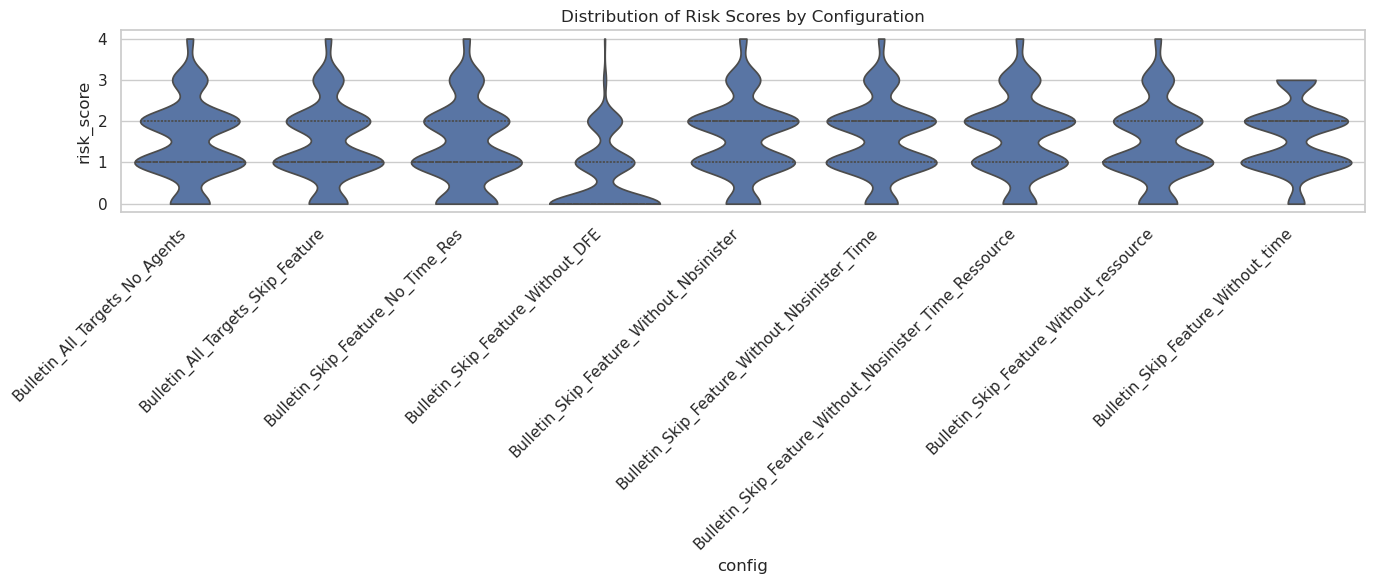

/tmp/ipykernel_534709/3648836914.py:31: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` for the same effect.
  ax = sns.violinplot(


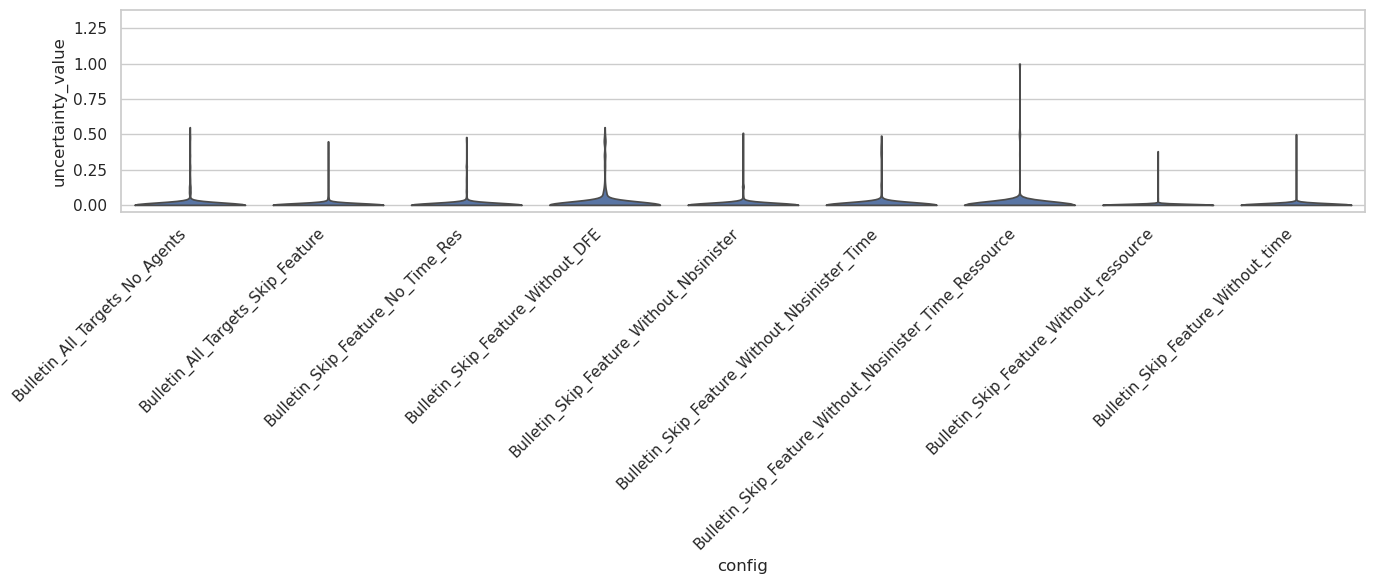

In [20]:
if data_frames:
    # =========================
    # Statistiques descriptives
    # =========================
    stats = all_data.groupby('config')[['risk_score', 'uncertainty_value']].agg(
        ['mean', 'median', 'std', 'min', 'max', 'count']
    )
    display(stats)

    # =========================
    # VIOLIN — Risk Score
    # =========================
    plt.figure(figsize=(14, 6))
    sns.violinplot(
        x='config',
        y='risk_score',
        data=all_data,
        inner='quartile',   # montre Q1, médiane, Q3
        cut=0,              # ne dépasse pas les données réelles
        scale='width'
    )
    plt.xticks(rotation=45, ha='right')
    plt.title("Distribution of Risk Scores by Configuration")
    plt.tight_layout()
    plt.show()

    # =========================
    # VIOLIN — Uncertainty
    # =========================
    plt.figure(figsize=(14, 6))
    ax = sns.violinplot(
        x='config',
        y='uncertainty_value',
        data=all_data,
        inner=None,        # on ajoute nos propres stats
        cut=0,
        scale='width'
    )

    plt.xticks(rotation=45, ha='right')

    # =========================
    # Compute stats
    # =========================
    grouped = all_data.groupby('config')['uncertainty_value']
    medians = grouped.median()
    means = grouped.mean()

    # Headroom for text
    ymin, ymax = ax.get_ylim()
    yr = ymax - ymin
    ax.set_ylim(ymin, ymax + 0.30 * yr)

    # =========================
    # Annotate Med & Mean
    # =========================
    for i, config in enumerate(medians.index):
        median = medians.loc[config]
        mean = means.loc[config]

        """ax.text(
            i, 0.97,
            rf"$\mathbf{{Med={median:.2f}\ |\ Mean={mean:.2f}}}$",
            transform=ax.get_xaxis_transform(),
            ha='center',
            va='top',
            fontsize=9
        )"""

    plt.tight_layout()
    plt.show()

risk_score         \
                                                         mean median   
config                                                                 
Bulletin_All_Targets_No_Agents                       1.513915    1.0   
Bulletin_All_Targets_Skip_Feature                    1.461967    1.0   
Bulletin_Skip_Feature_No_Time_Res                    1.377323    1.0   
Bulletin_Skip_Feature_Without_DFE                    0.671642    0.0   
Bulletin_Skip_Feature_Without_Nbsinister             1.575419    2.0   
Bulletin_Skip_Feature_Without_Nbsinister_Time        1.562152    2.0   
Bulletin_Skip_Feature_Without_Nbsinister_Time_R...   1.627561    2.0   
Bulletin_Skip_Feature_Without_ressource              1.480447    1.0   
Bulletin_Skip_Feature_Without_time                   1.612245    2.0   

                                                                            \
                                                         std min max count   
config                                                                       
Bulletin_All_Targets_No_Agents                      0.947159   0   4   539   
Bulletin_All_Targets_Skip_Feature                   0.946496   0   4   539   
Bulletin_Skip_Feature_No_Time_Res                   1.006870   0   4   538   
Bulletin_Skip_Feature_Without_DFE                   0.822816   0   4   536   
Bulletin_Skip_Feature_Without_Nbsinister            0.929608   0   4   537   
Bulletin_Skip_Feature_Without_Nbsinister_Time       0.913211   0   4   539   
Bulletin_Skip_Feature_Without_Nbsinister_Time_R...  0.947810   0   4   537   
Bulletin_Skip_Feature_Without_ressource             0.946365   0   4   537   
Bulletin_Skip_Feature_Without_time                  0.806524   0   3   539   

                                                   uncertainty_value         \
                                                                mean median   
config                                                                        
Bulletin_All_Targets_No_Agents                              0.011101    0.0   
Bulletin_All_Targets_Skip_Feature                           0.006865    0.0   
Bulletin_Skip_Feature_No_Time_Res                           0.008831    0.0   
Bulletin_Skip_Feature_Without_DFE                           0.020993    0.0   
Bulletin_Skip_Feature_Without_Nbsinister                    0.008284    0.0   
Bulletin_Skip_Feature_Without_Nbsinister_Time               0.012603    0.0   
Bulletin_Skip_Feature_Without_Nbsinister_Time_R...          0.010627    0.0   
Bulletin_Skip_Feature_Without_ressource                     0.001729    0.0   
Bulletin_Skip_Feature_Without_time                          0.005214    0.0   

                                                                               
                                                         std  min   max count  
config                                                                         
Bulletin_All_Targets_No_Agents                      0.056757  0.0  0.55   539  
Bulletin_All_Targets_Skip_Feature                   0.040767  0.0  0.45   539  
Bulletin_Skip_Feature_No_Time_Res                   0.048753  0.0  0.48   538  
Bulletin_Skip_Feature_Without_DFE                   0.081219  0.0  0.55   536  
Bulletin_Skip_Feature_Without_Nbsinister            0.050689  0.0  0.51   537  
Bulletin_Skip_Feature_Without_Nbsinister_Time       0.064760  0.0  0.49   539  
Bulletin_Skip_Feature_Without_Nbsinister_Time_R...  0.087801  0.0  1.00   537  
Bulletin_Skip_Feature_Without_ressource             0.022710  0.0  0.38   537  
Bulletin_Skip_Feature_Without_time                  0.038500  0.0  0.50   539

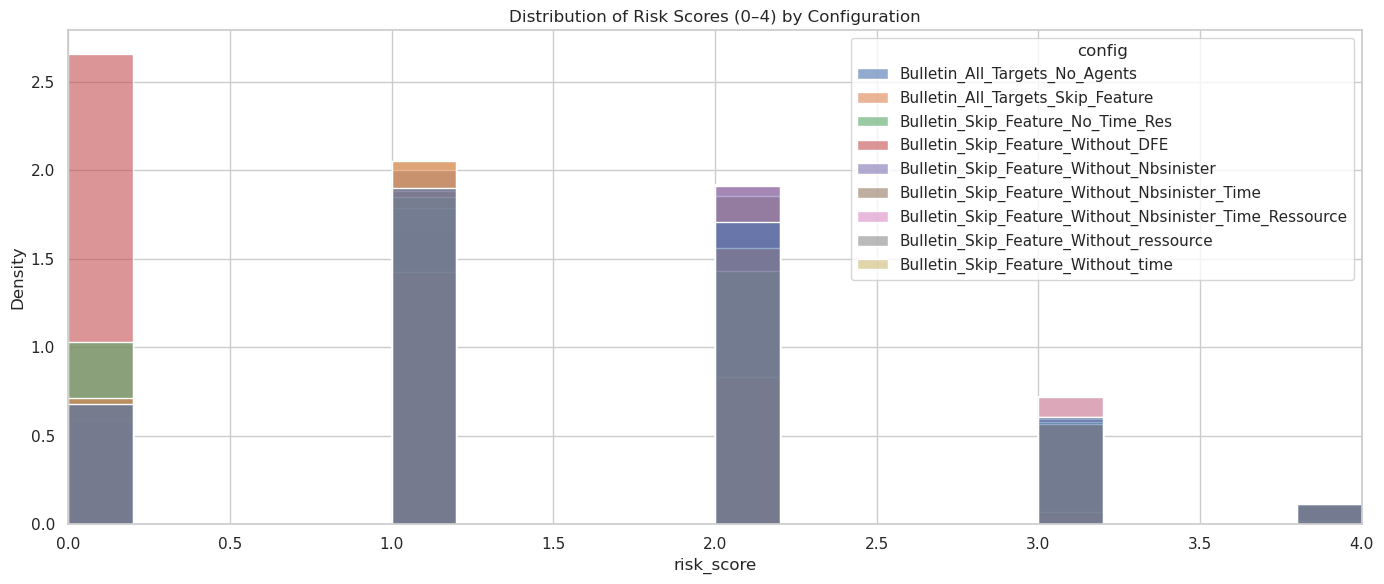

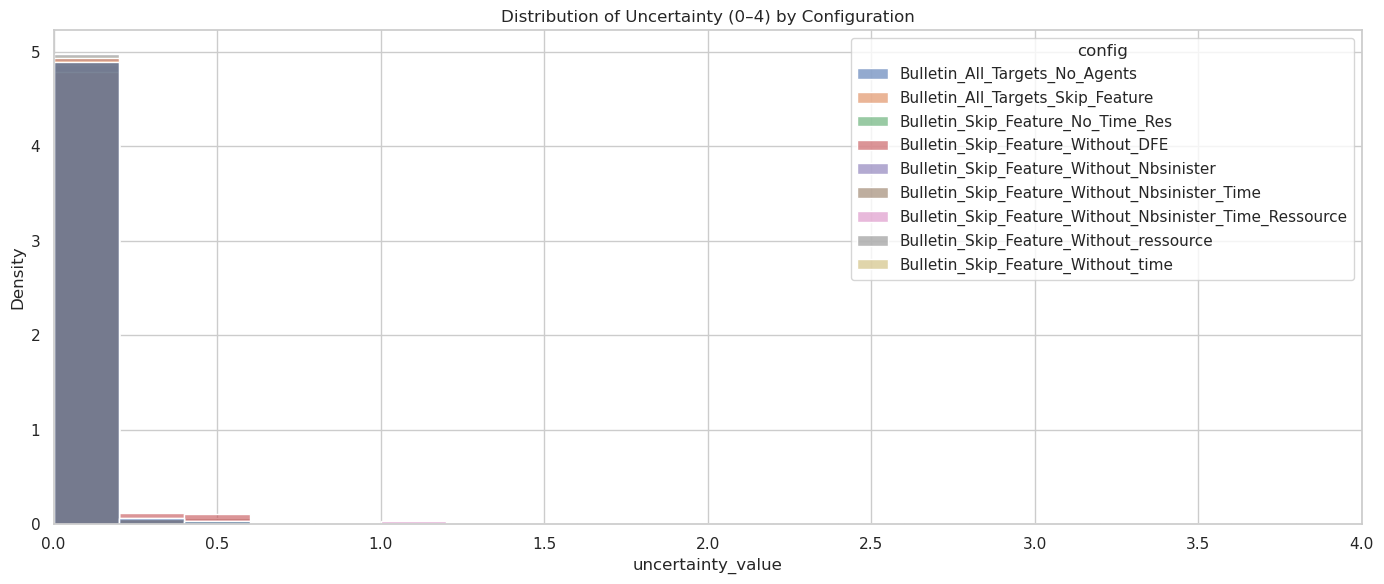

In [21]:
if data_frames:
    
    # =========================
    # Statistiques descriptives
    # =========================
    stats = all_data.groupby('config')[['risk_score', 'uncertainty_value']].agg(
        ['mean', 'median', 'std', 'min', 'max', 'count']
    )
    display(stats)

    # =========================
    # HISTOGRAM — Risk Score
    # =========================
    plt.figure(figsize=(14, 6))
    sns.histplot(
        data=all_data,
        x='risk_score',
        hue='config',
        bins=20,
        binrange=(0, 4),
        stat='density',
        common_norm=False,
        multiple='layer',
        element='bars',
        alpha=0.6
    )
    plt.xlim(0, 4)
    plt.title("Distribution of Risk Scores (0–4) by Configuration")
    plt.tight_layout()
    plt.show()

    # =========================
    # HISTOGRAM — Uncertainty
    # =========================
    plt.figure(figsize=(14, 6))
    sns.histplot(
        data=all_data,
        x='uncertainty_value',
        hue='config',
        bins=20,
        binrange=(0, 4),
        stat='density',
        common_norm=False,
        multiple='layer',
        element='bars',
        alpha=0.6
    )
    plt.xlim(0, 4)
    plt.title("Distribution of Uncertainty (0–4) by Configuration")
    plt.tight_layout()
    plt.show()


## 3. Comparaison par Rapport à la Référence (Baseline)

In [22]:
if BASELINE_CONFIG in data_frames:
    baseline_df = data_frames[BASELINE_CONFIG].copy()
    baseline_df = baseline_df[['date', 'num_zone', 'risk_score', 'uncertainty_value']]
    baseline_df.rename(columns={'risk_score': 'risk_score_base', 'uncertainty_value': 'uncertainty_base'}, inplace=True)

    comparison_metrics = []

    for config_name, df in data_frames.items():
        if config_name == BASELINE_CONFIG:
            continue
        
        # Merge on date and zone
        merged = pd.merge(df, baseline_df, on=['date', 'num_zone'], how='inner')
        
        if len(merged) == 0:
            print(f"Attention: Pas de correspondance de date/zone pour {config_name}")
            continue

        # Calculate metrics
        merged['risk_diff'] = merged['risk_score'] - merged['risk_score_base']
        merged['uncertainty_diff'] = merged['uncertainty_value'] - merged['uncertainty_base']
        
        mae_risk = merged['risk_diff'].abs().mean()
        std_risk_diff = merged['risk_diff'].std()
        mean_risk_diff = merged['risk_diff'].mean()
        
        mae_uncertainty = merged['uncertainty_diff'].abs().mean()
        mean_uncertainty_diff = merged['uncertainty_diff'].mean()

        comparison_metrics.append({
            'config': config_name,
            'MAE_Risk': mae_risk,
            'Mean_Diff_Risk': mean_risk_diff,
            'Std_Diff_Risk': std_risk_diff,
            'MAE_Uncertainty': mae_uncertainty,
            'Mean_Diff_Uncertainty': mean_uncertainty_diff,
            'Count': len(merged)
        })

    metrics_df = pd.DataFrame(comparison_metrics)
    if not metrics_df.empty:
        display(metrics_df.set_index('config'))
        
        # Plot MAE Risk
        plt.figure(figsize=(12, 6))
        sns.barplot(x='config', y='MAE_Risk', data=metrics_df)
        plt.xticks(rotation=45, ha='right')
        plt.title("MAE du Score de Risque par rapport à la Baseline")
        plt.tight_layout()
        plt.show()

        # Plot: Mean Uncertainty by Config
        plt.figure(figsize=(12, 6))
        sns.barplot(x='config', y='uncertainty_value', data=all_data, errorbar='sd')
        plt.xticks(rotation=45, ha='right')
        plt.title("Incertitude Moyenne par Expérience (avec Écart-Type)")
        plt.tight_layout()
        plt.show()

        # Plot: Comprehensive Metrics relative to Baseline
        # Reshape for grouped bar plot
        metrics_melted = metrics_df.melt(id_vars=['config'], 
                                         value_vars=['MAE_Risk', 'MAE_Uncertainty', 'Mean_Diff_Risk', 'Mean_Diff_Uncertainty'],
                                         var_name='Metric', value_name='Value')
        
        plt.figure(figsize=(14, 8))
        sns.barplot(x='config', y='Value', hue='Metric', data=metrics_melted)
        plt.xticks(rotation=45, ha='right')
        plt.title("Comparaison des Métriques par rapport à la Baseline")
        plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
        plt.tight_layout()
        plt.show()
    else:
        print("Aucune métrique calculée.")
else:
    print(f"La configuration de référence '{BASELINE_CONFIG}' n'a pas été trouvée.")

La configuration de référence 'Bulletin' n'a pas été trouvée.


## 5. Comparaison avec les Targets Originels (Ground Truth)

Évaluation de la performance des scores FARS par rapport aux données réelles (DFE, Feux, Temps d'intervention).

In [23]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os

1 / 1000

0.001

In [24]:
def plot_spline_effect_for_target_multi(
    df_long,
    cfg_names,
    target_label,
    df_spline=5,
    grid=None,
    ax=None,
    show=True,
    legend=True,
):
    """
    Trace plusieurs courbes d'effet spline (score -> E[Y]) sur une même target,
    une courbe par config.

    Parameters
    ----------
    df_long : pd.DataFrame
        Doit contenir: config, score, Y, num_zone, date.
    cfg_names : str | list[str]
        Une config (str) ou une liste de configs.
    target_label : str
        Label affiché (ex: "Taux", "Conso", etc.).
    df_spline : int
        df pour bs().
    grid : array-like | None
        Grille de score. Par défaut linspace(0,4,81).
    ax : matplotlib axis | None
        Pour dessiner sur un axe existant.
    show : bool
        Si True, plt.show() si ax est None.
    legend : bool
        Si True, affiche la légende.

    Returns
    -------
    dict[str, statsmodels.regression.linear_model.RegressionResultsWrapper]
        fits par config.
    """
    if isinstance(cfg_names, str):
        cfg_names = [cfg_names]

    if grid is None:
        grid = np.linspace(0, 4, 81)
    else:
        grid = np.asarray(grid)

    created_fig = False
    if ax is None:
        fig, ax = plt.subplots(figsize=(7, 5))
        created_fig = True

    fits = {}

    for cfg_name in cfg_names:
        d = (
            df_long[df_long["config"] == cfg_name]
            .dropna(subset=["score", "Y"])
            .copy()
        )

        if d.empty:
            print(f"[{target_label}] Pas de données pour config={cfg_name}")
            continue

        # Sécurité : scores dans [0,4]
        d["score"] = d["score"].clip(0, 4)

        formula = (
            f"Y ~ bs(score, df={df_spline}, degree=3, include_intercept=False,"
            f" lower_bound=0, upper_bound=4) + C(num_zone) + C(date)"
        )
        fit = smf.ols(formula, data=d).fit(cov_type="HC1")
        fits[cfg_name] = fit

        # Gabarit pour moyenner sur la distribution (num_zone, date) de la config
        template = d[["score", "num_zone", "date", "Y"]].copy()

        preds = []
        for s in grid:
            tmp = template.copy()
            tmp["score"] = float(s)
            v = fit.predict(tmp).mean()
            v = max(0, v)
            preds.append(v)
        preds = np.asarray(preds)

        ax.plot(grid, preds, label=str(cfg_name))

    ax.set_xlim(0, 4)
    ax.set_xlabel("score (0–4)")
    ax.set_ylabel(f"E[{target_label}] estimée")
    ax.set_title(f"{target_label} — Spline Effect (df={df_spline})")
    ax.grid(True, alpha=0.2)

    if legend and len(fits) > 0:
        ax.legend(title="config")

    if created_fig:
        plt.tight_layout()
        if show:
            plt.show()

    return fits

In [25]:
fire_df[(fire_df['nbsinister'] == 0) & (fire_df['ressource'] > 0)]

,Châtaignier_max,Chênes décidus_max,Chênes décidus_mean,Chênes sempervirents_max,Conifères_max,Conifères_mean,Corine_agricultural_max,Corine_agricultural_mean,Corine_forest_max,Corine_forest_mean,...,saison-cluster-encoder,timeintervention-quantile-5-Class-Dept,burnedarea-kmeans-5-Class-Dept,prediction_nbsinister-quantile-5-Class-Dept_0,prediction_nbsinister-quantile-5-Class-Dept_0_C0,prediction_nbsinister-quantile-5-Class-Dept_0_C1,prediction_nbsinister-quantile-5-Class-Dept_0_C2,prediction_nbsinister-quantile-5-Class-Dept_0_C3,prediction_nbsinister-quantile-5-Class-Dept_0_C4,num_zone


In [26]:
def lol(x, y):
    if x == 0 and y > 0:
        return 1
    return x

fire_df['nbsinister'] = fire_df.apply(lambda x : lol(x['nbsinister'], x['ressource']), axis=1)

In [27]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf
from patsy import bs


BASELINE_NAME = "Model (H0)" #### TRANSFORMER EN List avec GRU, LR, PERSISTENCE, WEEK_MAX et POISSON
SCORE_COL = "risk_score" ####### NE CHANGE PAS  #########
KEYS = ["date", "num_zone"] ######" NE CHANGE PAS ##########

dfe_df_filter = dfe_df[(dfe_df["date"] >= '2023-07-11') & (dfe_df["date"] <= '2023-09-24')]
fire_df_filter = fire_df[(fire_df["date"] >= '2023-07-11') & (fire_df["date"] <= '2023-09-24')]
res_df_filter = res_df[(res_df["date"] >= '2023-07-11') & (res_df["date"] <= '2023-09-24')]
time_df_filter = time_df[(time_df["date"] >= '2023-07-11') & (time_df["date"] <= '2023-09-24')]

dfe_key = dfe_df_filter[KEYS + ["DFE", "prediction_DFE_0"]].copy()

fire_df_filter = fire_df_filter.merge(dfe_key, on=KEYS, how="left")
res_df_filter  = res_df_filter.merge(dfe_key, on=KEYS, how="left")
time_df_filter = time_df_filter.merge(dfe_key, on=KEYS, how="left")

# Filter stats_results
for m in stats_results:
    for t in stats_results[m]:
        df = stats_results[m][t]
        if df is not None:
            # Ensure date column is handled correctly (string comparison as per original cell)
            stats_results[m][t] = df[(df["date"] >= '2023-07-11') & (df["date"] <= '2023-09-24')]


In [28]:
dfe_df_filter[dfe_df_filter['num_zone'] == 62]['DFE'].shape

(76,)

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf
from patsy import bs

def fit_spline_mu(dd: pd.DataFrame, df_spline: int = 5):
    d = dd.dropna(subset=["score", "Y", "num_zone", "date"]).copy()
    d["score"] = d["score"].clip(0, 4)

    formula = (
        f"Y ~ bs(score, df={df_spline}, degree=3, include_intercept=False, "
        f"lower_bound=0, upper_bound=4) + C(num_zone) + C(date)"
    )
    fit = smf.ols(formula, data=d).fit(cov_type="HC1")

    template = d[["score", "num_zone", "date"]].copy()
    mu = {}
    for s in LEVELS:
        tmp = template.copy()
        tmp["score"] = float(s)
        mu[s] = float(fit.predict(tmp).mean())
    return mu, fit

def get_spline_prediction(df: pd.DataFrame, x_col: str, y_col: str, df_spline: int = 5):
    """
    Fit a spline model Y ~ bs(X) + C(num_zone) + C(date) and return predictions.
    """
    d = df.dropna(subset=[x_col, y_col, "num_zone", "date"]).copy()
    d[x_col] = d[x_col].clip(0, 4)
    
    # Ensure num_zone and date are treated as categorical for fixed effects
    d["num_zone"] = d["num_zone"].astype("category")
    d["date"] = d["date"].astype("category")
    
    formula = (
        f"{y_col} ~ bs({x_col}, df={df_spline}, degree=3, include_intercept=False, "
        f"lower_bound=0, upper_bound=4) + C(num_zone) + C(date)"
    )
    fit = smf.ols(formula, data=d).fit(cov_type="HC1")
    
    # Predict on the original dataframe
    # We need to handle cases where some levels might be missing in df but present in d, 
    # but here we are predicting on the same df used for fitting (or a subset).
    preds = fit.predict(df)
    return preds.clip(0, 4)

def compute_passage_metrics_for_config(
    d: pd.DataFrame,
    df_spline: int = 5,
    min_n: int = 1,
    EXTRAPOLATION: bool = False,
    min_pairs_k: int = 1,   # optionnel: nb min de passages valides par k,
    min_gain=0.0
):
    dd = d.dropna(subset=["score", "Y"]).copy()
    dd["score"] = dd["score"].clip(0, 4)
    
    # niveaux discrets
    dd["_lvl"] = dd["score"].astype(int)

    # effectifs par niveau (0..4)
    lvl_counts = dd["_lvl"].value_counts().to_dict()
    support = set(lvl_counts.keys())

    mu, fit = fit_spline_mu(dd, df_spline=df_spline)

    if 4 in LEVELS:
        out = {
            "n": len(dd),
            "support": ",".join(map(str, sorted(support))),
            "mu0": mu[0], "mu1": mu[1], "mu2": mu[2], "mu3": mu[3], "mu4": mu[4],
        }
    else:
        out = {
            "n": len(dd),
            "support": ",".join(map(str, sorted(support))),
            "mu0": mu[0], "mu1": mu[1], "mu2": mu[2], "mu3": mu[3],
        }

    # utile pour debug
    for lvl in LEVELS:
        out[f"n_lvl_{lvl}"] = int(lvl_counts.get(lvl, 0))

    for k, pairs in PASSAGES.items():
        sub_deltas = []
        valid_pairs = 0

        for (a, b) in pairs:
            col = f"delta_{a}to{b}"
            
            # ---- règle Option B : passage valide seulement si assez de points des DEUX côtés
            n_a = lvl_counts.get(a, 0)
            n_b = lvl_counts.get(b, 0)

            # si EXTRAPOLATION=True, on peut calculer mu partout,
            # MAIS tu as demandé de ne "prendre en compte" le passage que s'il est vérifiable.
            # Donc on garde le filtre min_n même en extrapolation.
            if ((n_a >= min_n) and (n_b >= min_n)) or EXTRAPOLATION:
                min_g = min_gain if isinstance(min_gain, float) else min_gain[k - 1]
                delta = mu[b] - (mu[a] + min_g)
                out[col] = float(delta)
                sub_deltas.append(float(delta))
                valid_pairs += 1
            else:
                out[col] = np.nan

        sub = np.array(sub_deltas, dtype=float) if len(sub_deltas) else np.array([], dtype=float)

        out[f"eval_count_{k}"] = int(valid_pairs)  # nb de passages réellement pris en compte

        # ---- seuil optionnel par k : si pas assez de passages valides, on invalide le k
        if valid_pairs < min_pairs_k:
            out[f"avg_delta_{k}"] = np.nan
            out[f"min_delta_{k}"] = np.nan
            out[f"viol_rate_{k}"] = np.nan
            out[f"neg_mass_{k}"] = np.nan
        else:
            #out[f"avg_delta_{k}"] = float(np.mean(sub))
            out[f"avg_delta_{k}"] = float(np.median(sub))
            out[f"min_delta_{k}"] = float(np.min(sub))
            out[f"viol_rate_{k}"] = float(np.mean(sub < 0.0))
            out[f"neg_mass_{k}"] = float(np.mean(np.clip(-sub, 0.0, None)))
    
        print(k, np.unique(sub), len(sub), out[f"avg_delta_{k}"], out[f"min_delta_{k}"], out[f"viol_rate_{k}"], out[f"neg_mass_{k}"])

    dd.drop(columns=["_lvl"], inplace=True, errors="ignore")
    return out, fit

def estimate_passage_metrics_per_target(dflong: pd.DataFrame, df_spline=5, min_n=1, EXTRAPOLATION=False, min_gain=0.0) -> pd.DataFrame:
    rows = []
    for cfg, d in dflong.groupby("config"):
        m, _ = compute_passage_metrics_for_config(d, df_spline=df_spline, min_n=min_n, EXTRAPOLATION=EXTRAPOLATION, min_gain=min_gain)
        rows.append({"config": cfg, **m})

    return pd.DataFrame(rows).set_index("config")

# -----------------------------
# Scoring / plots
# -----------------------------
def build_matrix(all_metrics: dict, col: str) -> pd.DataFrame:
    return pd.DataFrame({t: all_metrics[t][col] for t in all_metrics})

def compute_score_for_k(all_metrics: dict, k: int, mode: str = "frt",
                        w_avg: float = 1.0, w_min: float = 1.0,
                        w_neg: float = 1.0, w_viol: float = 1.0) -> pd.DataFrame:
    if mode == "all4":
        targets = ["DFE", "Fire", "Res", "Time"]
    elif mode == "frt":
        targets = ["Fire", "Res", "Time"]
    else:
        raise ValueError("mode doit être 'all4' ou 'frt'.")
    targets = [t for t in targets if t in all_metrics]

    avg  = build_matrix(all_metrics, f"avg_delta_{k}_STD")[targets]
    mn   = build_matrix(all_metrics, f"min_delta_{k}_STD")[targets]
    neg  = build_matrix(all_metrics, f"neg_mass_{k}_STD")[targets]
    viol = build_matrix(all_metrics, f"viol_rate_{k}")[targets]
    cnt  = build_matrix(all_metrics, f"eval_count_{k}")[targets]

    out = pd.DataFrame(index=avg.index)
    out["AVG_SUM"] = avg.sum(axis=1, skipna=True)
    out["MIN_WORST"] = mn.min(axis=1, skipna=True)
    out["NEG_SUM"] = neg.sum(axis=1, skipna=True)
    out["VIOL_MAX"] = viol.max(axis=1, skipna=True)
    out["EVAL_TARGETS"] = avg.notna().sum(axis=1)
    out["EVAL_PAIRS_SUM"] = cnt.sum(axis=1, skipna=True)
    
    out.loc[out["EVAL_TARGETS"] == 0, ["AVG_SUM","MIN_WORST","NEG_SUM","VIOL_MAX"]] = np.nan

    out["SCORE"] = (
        (w_avg * out["AVG_SUM"]
        + w_min * out["MIN_WORST"]) / 2
        - w_neg * out["NEG_SUM"]
        * (1 + w_viol * out["VIOL_MAX"])
    )

    # Pondération douce par couverture (normalisée)
    denom = np.sqrt(out["EVAL_PAIRS_SUM"].max()) if out["EVAL_PAIRS_SUM"].max() > 0 else 1.0
    out["SCORE_ADJ"] = out["SCORE"] * (np.sqrt(out["EVAL_PAIRS_SUM"]))

    return out.sort_values("SCORE", ascending=False)

def plot_heatmap_k(all_metrics: dict, k: int, mode: str = "frt", top_n: int = 30,
                   fig_w: float = 28, row_h: float = 0.48, annot_font: int = 11,
                   fmt: str = ".2f", xrot: int = 25):
    ranked = compute_score_for_k(all_metrics, k=k, mode=mode)

    if mode == "all4":
        targets = ["DFE", "Fire", "Res", "Time"]
    else:
        targets = ["Fire", "Res", "Time"]
    targets = [t for t in targets if t in all_metrics]

    mat = build_matrix(all_metrics, f"avg_delta_{k}_STD")[targets]
    view = mat.join(
        ranked[["AVG_SUM","MIN_WORST","NEG_SUM","VIOL_MAX","SCORE","SCORE_ADJ"]],
        how="inner"
    )
    view = view.loc[ranked.index].head(top_n)
    
    fig_h = max(6, row_h * len(view))
    plt.figure(figsize=(fig_w, fig_h))
    ax = sns.heatmap(
        view,
        annot=True,
        fmt=fmt,
        center=0,
        cmap="coolwarm",
        annot_kws={"fontsize": annot_font},
        linewidths=0.4,
        linecolor="white"
    )
    plt.title(
        f"Spline passage +{k} (avec classe 4) — avg_delta_{k} standardisé (mode={mode})\n"
        f"NaN = sous-passages manquants ignorés (on continue avec ceux disponibles)",
        pad=12
    )
    plt.ylabel("Configuration (triée)")
    plt.xlabel("Targets + scoring")
    ax.set_xticklabels(ax.get_xticklabels(), rotation=xrot, ha="right")
    ax.set_yticklabels(ax.get_yticklabels(), rotation=0)
    plt.tight_layout()
    plt.show()
    return ranked, view

def compute_score_agg(all_metrics: dict, mode: str = "frt",
                      ks=(1,2,3,4),
                      alpha=None,
                      w_avg: float = 1.0, w_min: float = 1.0,
                      w_neg: float = 1.0, w_viol: float = 1.0) -> pd.DataFrame:
    """
    Construit un score agrégé sur plusieurs k.
    - Calcule SCORE_ADJ pour chaque k via compute_score_for_k
    - Agrège via somme pondérée.
    """
    if alpha is None:
        alpha = {k: 1.0 for k in ks}
    else:
        alpha = {k: float(alpha.get(k, 0.0)) for k in ks}

    per_k = {}
    for k in ks:
        rk = compute_score_for_k(
            all_metrics, k=k, mode=mode,
            w_avg=w_avg, w_min=w_min, w_neg=w_neg, w_viol=w_viol
        )
        per_k[k] = rk

    # Index commun = union de toutes les configs
    idx = sorted(set().union(*[df.index for df in per_k.values()]))

    out = pd.DataFrame(index=idx)
    for k in ks:
        out[f"SCORE_ADJ_k{k}"] = per_k[k].reindex(idx)["SCORE_ADJ"]
        out[f"SCORE_k{k}"] = per_k[k].reindex(idx)["SCORE"]
        out[f"EVAL_PAIRS_SUM_k{k}"] = per_k[k].reindex(idx)["EVAL_PAIRS_SUM"]

    # Somme pondérée (skipna -> ignore les k non évaluables)
    weighted = []
    for k in ks:
        weighted.append(alpha[k] * out[f"SCORE_ADJ_k{k}"])
    out["SCORE_AGG"] = pd.concat(weighted, axis=1).sum(axis=1, skipna=True)

    # Info: combien de k réellement évalués
    out["EVAL_K_COUNT"] = out[[f"SCORE_ADJ_k{k}" for k in ks]].notna().sum(axis=1)

    return out.sort_values("SCORE_AGG", ascending=False)

def compute_score_agg(all_metrics: dict, mode: str = "frt",
                      ks=(1,2,3,4),
                      alpha=None,
                      w_avg: float = 1.0, w_min: float = 1.0,
                      w_neg: float = 1.0, w_viol: float = 1.0) -> pd.DataFrame:
    """
    Construit un score agrégé sur plusieurs k.
    - Calcule SCORE_ADJ pour chaque k via compute_score_for_k
    - Agrège via somme pondérée.
    """
    if alpha is None:
        alpha = {k: 1.0 for k in ks}
    else:
        alpha = {k: float(alpha.get(k, 0.0)) for k in ks}

    per_k = {}
    for k in ks:
        rk = compute_score_for_k(
            all_metrics, k=k, mode=mode,
            w_avg=w_avg, w_min=w_min, w_neg=w_neg, w_viol=w_viol
        )
        per_k[k] = rk

    # Index commun = union de toutes les configs
    idx = sorted(set().union(*[df.index for df in per_k.values()]))

    out = pd.DataFrame(index=idx)
    for k in ks:
        out[f"SCORE_ADJ_k{k}"] = per_k[k].reindex(idx)["SCORE_ADJ"]
        out[f"SCORE_k{k}"] = per_k[k].reindex(idx)["SCORE"]
        out[f"EVAL_PAIRS_SUM_k{k}"] = per_k[k].reindex(idx)["EVAL_PAIRS_SUM"]

    # Somme pondérée (skipna -> ignore les k non évaluables)
    weighted = []
    for k in ks:
        weighted.append(alpha[k] * out[f"SCORE_ADJ_k{k}"])
    out["SCORE_AGG"] = pd.concat(weighted, axis=1).sum(axis=1, skipna=True)

    # Info: combien de k réellement évalués
    out["EVAL_K_COUNT"] = out[[f"SCORE_ADJ_k{k}" for k in ks]].notna().sum(axis=1)

    return out.sort_values("SCORE_AGG", ascending=False)

def plot_heatmap_agg(all_metrics: dict, mode: str = "frt", top_n: int = 30,
                     ks=(1,2,3),
                     alpha=None,
                     fig_w: float = 24, row_h: float = 0.55,
                     annot_font: int = 11, fmt: str = ".2f", xrot: int = 25):
    ranked = compute_score_agg(all_metrics, mode=mode, ks=ks, alpha=alpha)

    # Colonnes à afficher
    cols = ["SCORE_AGG", "EVAL_K_COUNT"] + [f"SCORE_ADJ_k{k}" for k in ks]

    view = ranked[cols].head(top_n)

    fig_h = max(6, row_h * len(view))
    plt.figure(figsize=(fig_w, fig_h))
    ax = sns.heatmap(
        view,
        annot=True,
        fmt=fmt,
        center=0,
        cmap="coolwarm",
        annot_kws={"fontsize": annot_font},
        linewidths=0.4,
        linecolor="white"
    )
    plt.title(
        f"Score agrégé (mode={mode}) — SCORE_AGG = Σ_k alpha_k * SCORE_ADJ_k\n"
        f"avec SCORE_ADJ_k = SCORE_k * sqrt(couverture) (NaN ignorés)",
        pad=12
    )
    plt.ylabel("Configuration (triée)")
    plt.xlabel("Agrégat + contributions par k")
    ax.set_xticklabels(ax.get_xticklabels(), rotation=xrot, ha="right")
    ax.set_yticklabels(ax.get_yticklabels(), rotation=0)
    plt.tight_layout()
    plt.show()
    return ranked, view

# ============================================================
# Pareto + LOW/HIGH + Coverage helpers
# ============================================================

def compute_score_low_high(
    all_metrics: dict,
    mode: str = "frt",
    low_ks=(1, 2),
    high_ks=(3, 4),
    use_adj: bool = False,
    **score_kwargs
) -> pd.DataFrame:
    """
    Construit une table par config avec:
      - SCORE_LOW = somme des SCORE_k (ou SCORE_ADJ_k) pour low_ks
      - SCORE_HIGH = somme des SCORE_k (ou SCORE_ADJ_k) pour high_ks

    Remarque:
      - use_adj=False => SCORE (non pondéré couverture)
      - use_adj=True  => SCORE_ADJ (pondéré couverture)
    """
    # calcule pour chaque k, puis join
    per_k = {}
    idx_union = set()
    for k in sorted(set(low_ks).union(high_ks)):
        rk = compute_score_for_k(all_metrics, k=k, mode=mode, **score_kwargs)
        per_k[k] = rk
        idx_union |= set(rk.index)

    idx = sorted(idx_union)
    out = pd.DataFrame(index=idx)
    for k, rk in per_k.items():
        col = "SCORE_ADJ" if use_adj else "SCORE"
        out[f"{col}_k{k}"] = rk.reindex(idx)[col]
        # couverture associée
        out[f"EVAL_PAIRS_SUM_k{k}"] = rk.reindex(idx)["EVAL_PAIRS_SUM"]

    col = "SCORE_ADJ" if use_adj else "SCORE"
    out["SCORE_LOW"] = out[[f"{col}_k{k}" for k in low_ks if f"{col}_k{k}" in out.columns]].sum(axis=1, skipna=True)
    out["SCORE_HIGH"] = out[[f"{col}_k{k}" for k in high_ks if f"{col}_k{k}" in out.columns]].sum(axis=1, skipna=True)

    # nb de k évalués dans chaque bloc
    out["LOW_K_COUNT"] = out[[f"{col}_k{k}" for k in low_ks if f"{col}_k{k}" in out.columns]].notna().sum(axis=1)
    out["HIGH_K_COUNT"] = out[[f"{col}_k{k}" for k in high_ks if f"{col}_k{k}" in out.columns]].notna().sum(axis=1)

    return out

def pareto_front_2d(df: pd.DataFrame, x_col: str, y_col: str, maximize: bool = True) -> pd.DataFrame:
    """
    Frontière de Pareto en 2D.
    - maximize=True : on veut grand x et grand y
    Renvoie le sous-DF des points non-dominés.
    """
    d = df[[x_col, y_col]].copy()
    d = d.dropna()
    if d.empty:
        return df.iloc[0:0].copy()

    # convertit en numpy
    pts = d.values
    keep = np.ones(len(d), dtype=bool)

    # Si minimize: on inverse les signes pour ramener à maximize
    if not maximize:
        pts = -pts

    for i in range(len(d)):
        if not keep[i]:
            continue
        xi, yi = pts[i, 0], pts[i, 1]
        dominates_i = (pts[:, 0] >= xi) & (pts[:, 1] >= yi) & ((pts[:, 0] > xi) | (pts[:, 1] > yi))
        dominates_i[i] = False
        #if dominates_i.any():
        #    keep[i] = False
    
    pareto_idx = d.index[keep]
    return df.loc[pareto_idx].copy()

def compute_coverage_levels(
    df_long: pd.DataFrame,
    score_col: str = "score",
    config_col: str = "config",
    levels=(0, 1, 2, 3, 4),
    passages: dict | None = None,
    ks=(1, 2, 3, 4),
) -> pd.DataFrame:
    """
    Pour chaque config, calcule:
      - n_level_s / frac_level_s
      - coverage_eff_k : somme_{(a,b) in PASSAGES[k]} min(n_a, n_b)
      - coverage_norm_k : coverage_eff_k / sum_j coverage_eff_j   (normalisation intra-config)
      - coverage_norm_sum : somme_k coverage_norm_k  (vaut ~1 si sum_eff>0 sinon 0)

    NOTE: "passages" par défaut = PASSAGES global du script.
    """
    if passages is None:
        passages = PASSAGES  # utilise le dict global défini plus haut

    d = df_long[[config_col, score_col]].dropna().copy()
    d[score_col] = pd.to_numeric(d[score_col], errors="coerce").clip(min(levels), max(levels))
    d = d.dropna(subset=[score_col]).copy()
    d[score_col] = d[score_col].astype(int)

    # counts par config et par niveau
    counts = (
        d.groupby([config_col, score_col])
         .size()
         .unstack(fill_value=0)
         .reindex(columns=list(levels), fill_value=0)
    )

    out = pd.DataFrame(index=counts.index)
    out["n_total"] = counts.sum(axis=1).astype(int)

    for s in levels:
        out[f"n_level_{s}"] = counts[s].astype(int)
        out[f"frac_level_{s}"] = counts[s] / out["n_total"].replace(0, np.nan)

    # --- coverage effective par k ---
    for k in ks:
        pairs = passages.get(k, [])
        eff = np.zeros(len(out), dtype=float)

        for (a, b) in pairs:
            na = out.get(f"n_level_{a}", pd.Series(0, index=out.index)).astype(float).values
            nb = out.get(f"n_level_{b}", pd.Series(0, index=out.index)).astype(float).values
            eff += np.minimum(na, nb)

        out[f"coverage_eff_k{k}"] = eff

    # --- normalisation intra-config (parts qui somment à 1) ---
    eff_cols = [f"coverage_eff_k{k}" for k in ks if f"coverage_eff_k{k}" in out.columns]
    sum_eff = out[eff_cols].sum(axis=1).replace(0, np.nan)

    for k in ks:
        col_eff = f"coverage_eff_k{k}"
        col_norm = f"coverage_norm_k{k}"
        if col_eff in out.columns:
            out[col_norm] = out[col_eff] / sum_eff
        else:
            out[col_norm] = np.nan

    # somme des coverages normalisés (≈1 si sum_eff>0, sinon 0)
    norm_cols = [f"coverage_norm_k{k}" for k in ks]
    out["coverage_norm_sum"] = out[norm_cols].sum(axis=1, skipna=True).fillna(0.0)

    return out

from mpl_toolkits.axes_grid1 import make_axes_locatable

def abbreviate_config(name: str) -> str:
    """
    Règles d’abréviation des configs :
    - DFE_score -> DFE
    - Model (H0) -> GRU
    - sinon : première lettre de chaque token séparé par '_'
    """
    if name == "DFE_score":
        return "DFE"
    if name == "Model (H0)":
        return "Model (H0)"

    parts = str(name).split("_")
    abbr = "".join(p[0].upper() for p in parts if isinstance(p, str) and len(p) > 0)
    return abbr


ALL_BASELINE_NAME = "All Model (H0)"


import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib import colors as mcolors


def plot_pareto_low_high(
    scores_low_high: pd.DataFrame,
    coverage_df: pd.DataFrame | None = None,
    title: str = "Pareto SCORE_LOW vs SCORE_HIGH",
    annotate_top: int = 8,
    point_size_base: float = 40.0,
    size_by: str | None = None,
    size_scale: float = 0.02,
    color_by: str | None = None,
    show_coverage_text: str | None = "k",
    annotate_all: bool = True,
    all_fontsize: int = 8,
    all_alpha: float = 0.8,
    legend: bool = True,
    legend_only_pareto: bool = False,
    legend_fontsize: int = 8,
    skip_4 = False,
    top2_agg=None,
    plot=True
):
    """
    Pareto SCORE_LOW vs SCORE_HIGH avec :
      - taille = size_by
      - couleur = color_by
      - colorbar horizontale sous le plot
      - légende dont les points suivent la couleur réelle du coverage
    """
    
    def describe_config(name: str) -> str:
        s = str(name)

        # Cas simples
        if s == "DFE_score":
            return "DFE score risk score"

        if s == "Model (H0)":
            return "Single-target as risk score"

        if s.startswith("All Model (H0)"):
            return "1st and 2nd weighted aggregation of Fire / Res / Time / DFE predictions"

        s = s.replace("Bulletin", "FARS")
        return s

    # ---------------- helpers ----------------
    def abbreviate_config(name: str, top2_agg=None) -> str:
        if name == "DFE_score":
            return "DFE"
        if name == "Model (H0)":
            return "Model (H0)"

        if top2_agg is not None:
            if len(top2_agg) > 0 and name == top2_agg[0]:
                return "ALL_MODEL_1"
            if len(top2_agg) > 1 and name == top2_agg[1]:
                return "ALL_MODEL_2"
            
        # fallback: abréviation automatique
        return "".join(p[0].upper() for p in str(name).split("_") if p)
    
    def make_unique_abbr(index, top2_agg):
        used, out = {}, {}
        for cfg in index:
            base = abbreviate_config(cfg, top2_agg=top2_agg)

            if base not in used:
                used[base] = 1
                out[cfg] = base
            else:
                used[base] += 1
                out[cfg] = f"{base}{used[base]}"
        return out

    def coverage_text(cfg, row):
        if show_coverage_text == "k":
            parts = []
            for k in [1, 2, 3, 4]:
                if k == 4 and skip_4:
                    continue
                col = f"coverage_eff_k{k}"
                if col in row and pd.notna(row[col]):
                    parts.append(f"k{k}:{int(row[col])}")
            return " ".join(parts)
        return ""

    # ---------------- data ----------------
    d = scores_low_high.copy()
    if coverage_df is not None:
        d = d.join(coverage_df, how="left")

    pareto = pareto_front_2d(d, "SCORE_LOW", "SCORE_HIGH", maximize=True)
    abbr_map = make_unique_abbr(d.index, top2_agg)

    # ---------------- size ----------------
    if size_by and size_by in d.columns:
        sizes = point_size_base + size_scale * d[size_by].fillna(0).astype(float)
    else:
        sizes = point_size_base

    # ---------------- color ----------------
    cvals = None
    norm = None
    cmap = plt.cm.viridis

    if color_by and color_by in d.columns:
        cvals = pd.to_numeric(d[color_by], errors="coerce")
        norm = mcolors.Normalize(vmin=cvals.min(), vmax=cvals.max())

    if plot:
        # ---------------- plot ----------------
        fig, (ax, ax_desc) = plt.subplots(
        1, 2,
        figsize=(18, 8),
        gridspec_kw={"width_ratios": [3, 1]}
        )
        ax_desc.axis("off")


        sc = ax.scatter(
            d["SCORE_LOW"],
            d["SCORE_HIGH"],
            s=sizes,
            c=cvals if cvals is not None else None,
            cmap=cmap if cvals is not None else None,
            norm=norm,
            alpha=0.7,
        )

        # Pareto highlight
        ax.scatter(
            pareto["SCORE_LOW"],
            pareto["SCORE_HIGH"],
            s=sizes.loc[pareto.index] if hasattr(sizes, "loc") else sizes,
            facecolors="none",
            edgecolors="black",
            linewidth=1.2,
        )

        ax.set_xlabel("SCORE_LOW")
        ax.set_ylabel("SCORE_HIGH")
        ax.set_title(title)
        ax.grid(True, alpha=0.25)
        
        # ------------------------------------------------
        # Right panel: description of experiments
        # ------------------------------------------------
        y_pos = 0.98

        for cfg in d.index:
            short = abbreviate_config(cfg, top2_agg=top2_agg)
            
            if '_2' in short:
                continue
            if '_1' in short:
                short = 'ALL_MODEL_X'
            
            long = describe_config(cfg)

            text = f"{short}\n{long}"

            ax_desc.text(
                0.02, y_pos,
                text,
                fontsize=10,
                va="top",
                linespacing=1.6
            )

            # Descente verticale suffisante pour une "entrée"
            y_pos -= 0.08


        # ---------------- annotations ----------------
        if annotate_all:
            for cfg, row in d.iterrows():
                if pd.isna(row["SCORE_LOW"]) or pd.isna(row["SCORE_HIGH"]):
                    continue
                ax.annotate(
                    abbr_map[cfg],
                    (row["SCORE_LOW"], row["SCORE_HIGH"]),
                    fontsize=all_fontsize,
                    alpha=all_alpha,
                    xytext=(3, 3),
                    textcoords="offset points",
                )

        # ---------------- colorbar (horizontal) ----------------
        if cvals is not None:
            cb = fig.colorbar(
                sc,
                ax=ax,
                orientation="horizontal",
                pad=0.14,
                fraction=0.06,
                aspect=35,
            )
            cb.set_label(color_by)

        # ---------------- legend with colored markers ----------------
        if legend:
            legend_cfgs = pareto.index if legend_only_pareto else d.index

            handles, labels = [], []
            for cfg in legend_cfgs:
                if cfg not in d.index:
                    continue

                row = d.loc[cfg]
                abbr = abbr_map[cfg]
                txt = coverage_text(cfg, row)
                label = f"{abbr}: {txt}" if txt else abbr

                if cvals is not None and pd.notna(row[color_by]):
                    color = cmap(norm(row[color_by]))
                else:
                    color = "gray"

                handles.append(
                    Line2D(
                        [0], [0],
                        marker="o",
                        linestyle="None",
                        markerfacecolor=color,
                        markeredgecolor="black",
                        markersize=7,
                    )
                )
                labels.append(label)

            ax.legend(
                handles,
                labels,
                fontsize=legend_fontsize,
                title="Coverage",
                frameon=True,
                loc="upper left",
                bbox_to_anchor=(1.02, 0.25),
            )

        plt.tight_layout()
        plt.show()
    return pareto


import pandas as pd

def build_master_pred_df(
    dfe_df_filter: pd.DataFrame | None,
    fire_df_filter: pd.DataFrame | None,
    res_df_filter: pd.DataFrame | None,
    time_df_filter: pd.DataFrame | None,
) -> pd.DataFrame:
    """
    Builds a master DF on KEYS with any available signals among:
      - DFE
      - pred_fire
      - pred_res
      - pred_time

    Each input DF can be None (it will simply be skipped).
    The output contains KEYS + the available prediction columns.
    """

    # Map each optional DF to: (df, required_source_col, output_col_name, source_name)
    col_fire = f"prediction_nbsinister-{clustering}-5-Class-Dept_0"
    col_res  = f"prediction_ressource-{clustering}-5-Class-Dept_0"
    col_time = f"prediction_timeintervention-{clustering}-5-Class-Dept_0"

    sources = [
        (dfe_df_filter, "DFE",      "DFE",       "dfe_df_filter"),
        (fire_df_filter, col_fire,  "pred_fire", "fire_df_filter"),
        (res_df_filter,  col_res,   "pred_res",  "res_df_filter"),
        (time_df_filter, col_time,  "pred_time", "time_df_filter"),
    ]

    # Keep only provided DFs
    provided = [(df, src_col, out_col, name) for (df, src_col, out_col, name) in sources if df is not None]
    if not provided:
        raise ValueError("All inputs are None: nothing to merge.")

    # Prepare each DF (types + column presence + select/rename)
    prepared = []
    for df, src_col, out_col, name in provided:
        tmp = df.copy()

        # basic key typing
        if "date" in tmp.columns:
            tmp["date"] = pd.to_datetime(tmp["date"])
        if "num_zone" in tmp.columns:
            tmp["num_zone"] = tmp["num_zone"].astype(int)

        # check columns
        missing = [c for c in (KEYS + [src_col]) if c not in tmp.columns]
        if missing:
            raise ValueError(f"Missing column(s) {missing} in {name}.")

        tmp = tmp[KEYS + [src_col]].rename(columns={src_col: out_col})
        prepared.append(tmp)

    # Inner-merge all provided sources on KEYS
    m = prepared[0]
    for tmp in prepared[1:]:
        m = m.merge(tmp, on=KEYS, how="inner")

    # numeric + clip for prediction-like columns
    pred_like_cols = [c for c in ["DFE", "pred_fire", "pred_res", "pred_time"] if c in m.columns]
    for c in pred_like_cols:
        m[c] = pd.to_numeric(m[c], errors="coerce").clip(0, 4)
    
    # drop rows with NaN in available columns
    return m.dropna(subset=pred_like_cols).copy()

ALL_BASELINE_NAME = "All Model (H0)"

def build_allmodel_score_configs(
    master_pred: pd.DataFrame,
    weight_grid=None,
    w_dfe_grid=None,
    normalize_weights=True,   # <- recommandé
    fire_col="pred_fire",
    res_col="pred_res",
    time_col="pred_time",
    dfe_col="_pred_dfe",
):
    """
    Retourne un DF long: KEYS + config + score
    score = wF*pred_fire + wR*pred_res + wT*pred_time + wD*pred_dfe
    où wD provient de w_dfe_grid (incluant 0.0).
    """

    if weight_grid is None:
        weight_grid = [
            (1.00, 0.00, 0.00),
            (0.00, 1.00, 0.00),
            (0.00, 0.00, 1.00),
            
            (0.75, 0.25, 0.00),
            (0.75, 0.00, 0.25),
            (0.25, 0.75, 0.00),
            (0.00, 0.75, 0.25),
            (0.25, 0.00, 0.75),
            (0.00, 0.25, 0.75),

            (0.50, 0.50, 0.00),
            (0.50, 0.00, 0.50),
            (0.00, 0.50, 0.50),

            (0.50, 0.25, 0.25),
            (0.25, 0.50, 0.25),
            (0.25, 0.25, 0.50),

            (1/3, 1/3, 1/3),
        ]
        
    if w_dfe_grid is None:
        w_dfe_grid = [0.0, 0.25, 0.5, 1.0]

    d = master_pred.copy()

    # Check which columns are actually available
    available_cols = []
    for c in [fire_col, res_col, time_col, dfe_col]:
        if c in d.columns:
            available_cols.append(c)
        elif c == dfe_col:
            # Special case for DFE if not already in d
            if "DFE" in d.columns:
                d[dfe_col] = pd.to_numeric(d["DFE"], errors="coerce")
                available_cols.append(dfe_col)
            else:
                raise ValueError("DFE column (Ground Truth) is missing from the dataframe. Comparison Analysis allows only 'DFE'.")

    if not available_cols:
        raise ValueError("Aucune des colonnes de prédiction demandées n'est disponible.")

    for c in available_cols:
        d[c] = pd.to_numeric(d[c], errors="coerce").clip(0, 4)

    d = d.dropna(subset=available_cols).copy()

    rows = []

    for (wF, wR, wT) in weight_grid:
        for wD in w_dfe_grid:
            # Map weights to available columns
            weights = {
                fire_col: wF,
                res_col: wR,
                time_col: wT,
                dfe_col: wD
            }
            
            # Filter weights for available columns only
            active_weights = {c: weights[c] for c in available_cols}
            
            if normalize_weights:
                s = sum(active_weights.values())
                if s == 0:
                    normalized_weights = {c: 0.0 for c in available_cols}
                else:
                    normalized_weights = {c: w/s for c, w in active_weights.items()}
            else:
                normalized_weights = active_weights
        
            score = sum(normalized_weights[c] * d[c].astype(float) for c in available_cols).clip(0, 4).round()

            cfg = (
                f"{ALL_BASELINE_NAME}_"
                f"w{wF:.2f}-{wR:.2f}-{wT:.2f}_"
                f"dfe{wD:.2f}_"
                f"{'norm' if normalize_weights else 'raw'}"
            )
            
            out = d[KEYS].copy()
            out["config"] = cfg
            out["score"] = score
            
            rows.append(out)

    return pd.concat(rows, ignore_index=True)

import numpy as np
import pandas as pd

def _latex_escape(s: str) -> str:
    """Escape minimal pour LaTeX (surtout underscores)."""
    if s is None:
        return ""
    s = str(s)
    return (s.replace("\\", "\\textbackslash{}")
             .replace("_", "\\_")
             .replace("%", "\\%")
             .replace("&", "\\&")
             .replace("#", "\\#")
             .replace("{", "\\{")
             .replace("}", "\\}")
             .replace("$", "\\$")
             .replace("~", "\\textasciitilde{}")
             .replace("^", "\\textasciicircum{}"))

def pareto_low_high_to_latex_table(
    scores_low_high: pd.DataFrame,
    coverage_df: pd.DataFrame | None = None,
    per_k_scores: pd.DataFrame | None = None,
    # per_k_scores optionnel: si tu veux override SCORE_kx, sinon on le calcule depuis all_metrics (voir autre helper)
    title: str | None = None,
    caption: str | None = None,
    label: str | None = None,
    only_pareto: bool = False,
    top_n: int | None = None,
    float_fmt: str = "{:.3f}",
    skip_4: bool = False,
) -> str:
    """
    Retourne une string LaTeX (tabular) avec colonnes:
    config, SCORE_LOW, SCORE_HIGH, Coverage, SCORE_k1..SCORE_k4.
    Les NaN sont remplacés par '-'.

    Paramètres:
    - scores_low_high: output de compute_score_low_high (doit contenir SCORE_LOW, SCORE_HIGH).
    - coverage_df: output de compute_coverage_levels (contient coverage_eff_k1..k4).
    - per_k_scores: DF optionnel index=config avec colonnes SCORE_k1..SCORE_k4 déjà prêtes.
      (si None, on tentera de prendre SCORE_ADJ_kx/SCORE_kx présents dans scores_low_high, sinon '-')
    - only_pareto: si True, filtre sur la frontière de Pareto (via ta fonction pareto_front_2d existante).
    - top_n: si donné, garde les top_n lignes triées par (SCORE_LOW + SCORE_HIGH) décroissant (après filtres).
    """

    # --- Join data ---
    d = scores_low_high.copy()
    
    if coverage_df is not None:
        d = d.join(coverage_df, how="left")
        
    # --- Pareto filter option (utilise ta fonction existante) ---
    if only_pareto:
        # suppose que pareto_front_2d est déjà défini dans ton script
        d = pareto_front_2d(d, "SCORE_LOW", "SCORE_HIGH", maximize=True)

    # --- Build SCORE_k1..k4 ---
    # Cas 1: per_k_scores fourni
    if per_k_scores is not None:
        for k in [1, 2, 3, 4]:
            col = f"SCORE_k{k}"
            if col in per_k_scores.columns:
                d[col] = per_k_scores.reindex(d.index)[col]
    else:
        # Cas 2: tenter de récupérer des colonnes déjà présentes (SCORE_ADJ_kx ou SCORE_kx)
        for k in [1, 2, 3, 4]:
            if f"SCORE_k{k}" in d.columns:
                continue
            if f"SCORE_ADJ_k{k}" in d.columns:
                d[f"SCORE_k{k}"] = d[f"SCORE_ADJ_k{k}"]
            else:
                d[f"SCORE_k{k}"] = np.nan

    # --- Coverage text ---
    def coverage_text(row) -> str:
        parts = []
        for k in [1, 2, 3, 4]:
            if skip_4 and k == 4:
                continue
            col = f"coverage_eff_k{k}"
            if col in row and pd.notna(row[col]):
                parts.append(f"k{k}:{int(row[col])}")
        return " ".join(parts)

    d["Coverage"] = d.apply(coverage_text, axis=1) if coverage_df is not None else ""

    # --- Select/Order columns ---
    cols = ["SCORE_LOW", "SCORE_HIGH", "Coverage"] + [f"SCORE_k{k}" for k in [1, 2, 3, 4]]
    out = d[cols].copy()
    out.insert(0, "config", out.index.map(str))

    # --- Optional ranking / trimming ---
    out["_rank"] = pd.to_numeric(out["SCORE_LOW"], errors="coerce").fillna(0) + pd.to_numeric(out["SCORE_HIGH"], errors="coerce").fillna(0)
    out = out.sort_values("_rank", ascending=False).drop(columns=["_rank"])
    if top_n is not None:
        out = out.head(int(top_n))

    # --- Formatting: NaN -> '-' and floats -> float_fmt ---
    def fmt_cell(x):
        if x is None or (isinstance(x, float) and np.isnan(x)):
            return "-"
        # strings (Coverage, config)
        if isinstance(x, str):
            return _latex_escape(x)
        # numbers
        try:
            xf = float(x)
            if np.isnan(xf):
                return "-"
            return float_fmt.format(xf)
        except Exception:
            return _latex_escape(str(x))

    out_fmt = out.copy()
    for c in out_fmt.columns:
        out_fmt[c] = out_fmt[c].map(fmt_cell)

    # --- Build LaTeX (manual tabular, robuste) ---
    col_spec = "l" + "r" * (len(out_fmt.columns) - 1)
    header = " & ".join(out_fmt.columns) + " \\\\"

    lines = []
    lines.append("\\begin{table}[ht]")
    lines.append("\\centering")
    if title:
        lines.append(f"\\textbf{{{_latex_escape(title)}}}\\\\")
    lines.append(f"\\begin{{tabular}}{{{col_spec}}}")
    lines.append("\\hline")
    lines.append(header)
    lines.append("\\hline")

    for _, row in out_fmt.iterrows():
        lines.append(" & ".join(row.values.tolist()) + " \\\\")

    lines.append("\\hline")
    lines.append("\\end{tabular}")
    if caption:
        lines.append(f"\\caption{{{_latex_escape(caption)}}}")
    if label:
        lines.append(f"\\label{{{_latex_escape(label)}}}")
    lines.append("\\end{table}")

    return "\n".join(lines)

In [30]:
# -----------------------------
# Long format builders
# -----------------------------
def build_long_scores_from_dfe_df(dfe_df: pd.DataFrame, config_name: str = "DFE_score") -> pd.DataFrame:
    d = dfe_df.copy()
    d["date"] = pd.to_datetime(d["date"])
    d["num_zone"] = d["num_zone"].astype(int)
    if "DFE" not in d.columns:
        raise ValueError("La colonne 'DFE' est absente de dfe_df.")
    out = d[KEYS + ["DFE"]].copy()
    out["config"] = config_name
    out = out.rename(columns={"DFE": "score"})
    return out

def build_long_scores_from_fwi(df: pd.DataFrame, config_name="FWI_score") -> pd.DataFrame:
    d = df.copy()
    d["date"] = pd.to_datetime(d["date"])
    d["num_zone"] = d["num_zone"].astype(int)
    if "fwi_mean" not in d.columns:
        raise ValueError("La colonne 'fwi_mean' est absente de dfe_df.")
    out = d[KEYS + ["fwi_mean"]].copy()
    out["config"] = config_name
    out = out.rename(columns={"fwi_mean": "score"})
    return out

def build_long_scores_configs(risk_all: pd.DataFrame) -> pd.DataFrame:
    d = risk_all.copy()
    d["date"] = pd.to_datetime(d["date"])
    d["num_zone"] = d["num_zone"].astype(int)

    if "config" not in d.columns:
        raise ValueError("risk_all doit contenir une colonne 'config'.")
    if SCORE_COL not in d.columns:
        raise ValueError(f"risk_all doit contenir la colonne '{SCORE_COL}'.")

    real = d[KEYS + ["config", SCORE_COL]].copy()
    res = real.rename(columns={SCORE_COL: "score"})
    
    return res

def build_long_scores_h0_from_gt(gt_df: pd.DataFrame, y_col: str, config_name: str) -> pd.DataFrame:
    if y_col in ["nbsinister", "time_intervention", "ressource"]:
        if y_col == "time_intervention":
            baseline_col = f"prediction_timeintervention-{clustering}-5-Class-Dept_0"
        else:
            baseline_col = f"prediction_{y_col}-{clustering}-5-Class-Dept_0"
    else:
        baseline_col = f"prediction_{y_col}_0"

    g = gt_df.copy()
    g["date"] = pd.to_datetime(g["date"])
    g["num_zone"] = g["num_zone"].astype(int)

    if baseline_col not in g.columns:
        # Fallback if prediction column is missing (should not happen if loaded correctly)
        raise ValueError(f"Colonne baseline '{baseline_col}' absente du dataframe target.")

    base = g[KEYS + [baseline_col]].copy()
    base["config"] = config_name
    base = base.rename(columns={baseline_col: "score"})
    return base

def prepare_long_for_target(
    risk_all: pd.DataFrame,
    gt_df: pd.DataFrame,
    y_col: str,
    add_dfe_score_as_config: bool = False,
    add_fwi_score_as_config: bool = False,
    dfe_df: pd.DataFrame | None = None,
    dfe_config_name: str = "DFE_score",
    fwi_config_name: str = "FWI_score",
    extra_scores: list[pd.DataFrame] | None = None,
    h0_config_name: str = "Model (H0)"
) -> pd.DataFrame:
    
    real = build_long_scores_configs(risk_all)
    h0 = build_long_scores_h0_from_gt(gt_df, y_col, config_name=h0_config_name)
    parts = [real, h0]

    if extra_scores:
        parts.extend(extra_scores)

    if add_dfe_score_as_config and dfe_df is not None:
        dfe_long = build_long_scores_from_dfe_df(dfe_df, config_name=dfe_config_name)
        parts.append(dfe_long)

    if add_fwi_score_as_config and dfe_df is not None:
        fwi_long = build_long_scores_from_fwi(dfe_df, config_name=fwi_config_name)
        parts.append(fwi_long)
        
    df_long = pd.concat(parts, ignore_index=True)
    
    # Add Y column from gt_df
    y_ref = gt_df[KEYS + [y_col]].copy()
    y_ref["date"] = pd.to_datetime(y_ref["date"])
    y_ref["num_zone"] = y_ref["num_zone"].astype(int)
    y_ref = y_ref.rename(columns={y_col: "Y"})
    df_long = df_long.merge(y_ref, on=KEYS, how="left")
    df_long.drop_duplicates(('date', 'num_zone', 'config'), inplace=True)
    return df_long

In [31]:
from sklearn.preprocessing import MinMaxScaler

min_max_fire = MinMaxScaler().fit(train_fire_df['nbsinister'].values.reshape(-1,1))
min_max_res = MinMaxScaler().fit(train_fire_df['ressource'].values.reshape(-1,1))
min_max_time = MinMaxScaler().fit(train_fire_df['time_intervention'].values.reshape(-1,1))

min_max_dict = {
     'nbsinister' : min_max_fire,
    'ressource' : min_max_res,
    'time_intervention' : min_max_time   
 }

In [32]:

def min_max(df, target):
    if df is None:
        return None
    
    scaler = min_max_dict[target]
    df[target] = scaler.transform(df[target].values.reshape(-1,1))
    return df

################# fire_df_filter, res_df_filter, time_df_filter doivent etre trasnformé en List (1 élément par modèle) ##############
def run_pareto_top2_aggregation(
    data_frames: dict,
    TARGETS: dict,
    dfe_df_filter: pd.DataFrame,
    fire_df_filter: list,
    res_df_filter: list,
    time_df_filter: list,
    dfe_df: pd.DataFrame,
    *,
    apply_normalisation : bool = False,
    EXTRAPOLATION: bool = True,
    df_spline=5,
    min_n=1,
    agg_prefix="All Model (H0)",
    keep_baselines=["DFE_score", "Model (H0)"],
    low_ks=(1, 2),
    high_ks=(3, 4),
    title="",
    plot=True,
    add_agreggate=False,
    agregate_type='Spline',
    size_by="coverage_eff_total",
    color_by="coverage_eff_total",
    model_names: list | None = None,
    min_gain : list | float = 0.0,
):
    # Ensure inputs are lists
    if not isinstance(fire_df_filter, list): fire_df_filter = [fire_df_filter]
    if not isinstance(res_df_filter, list): res_df_filter = [res_df_filter]
    if not isinstance(time_df_filter, list): time_df_filter = [time_df_filter]

    # -----------------------------
    # Build risk_allscores_lh_plot
    # -----------------------------
    risk_all_base = pd.concat(data_frames.values(), ignore_index=True)
    
    all_df_long_by_target = {t: [] for t in TARGETS}

    # Loop over models
    for i in range(len(fire_df_filter)):
        f_df = fire_df_filter[i]
        r_df = res_df_filter[i] if i < len(res_df_filter) else None
        t_df = time_df_filter[i] if i < len(time_df_filter) else None
        
        suffix = f"_{i}" if len(fire_df_filter) > 1 else ""
        current_agg_prefix = f"{agg_prefix}{suffix}"
        
        # Determine H0 config name
        if model_names and i < len(model_names):
            current_h0_name = model_names[i]
        elif isinstance(BASELINE_NAME, list) and i < len(BASELINE_NAME):
            current_h0_name = BASELINE_NAME[i]
        else:
            current_h0_name = f"Model (H0){suffix}"
            
        if apply_normalisation:
            if f_df is not None: f_df = min_max(f_df.copy(), 'nbsinister')
            if t_df is not None: t_df = min_max(t_df.copy(), 'time_intervention')
            if r_df is not None: r_df = min_max(r_df.copy(), 'ressource')
        
        # Build master_pred (raw predictions)
        master_pred = build_master_pred_df(
            dfe_df_filter, f_df, r_df, t_df
        )
        
        # Build df_long per target
        for target_name, (gt_var, y_col) in TARGETS.items():
            
            if gt_var == "fire_df_filter":
                current_gt_df = f_df
            elif gt_var == "res_df_filter":
                current_gt_df = r_df
            elif gt_var == "time_df_filter":
                current_gt_df = t_df
            elif gt_var == "dfe_df_filter":
                current_gt_df = dfe_df_filter

            if current_gt_df is None: continue
            
            if add_agreggate:

                # Fix for missing DFE column
                if "DFE" not in current_gt_df.columns:
                    current_gt_df = current_gt_df.merge(dfe_df_filter[KEYS + ["DFE"]], on=KEYS, how="left")
                
                m_target = master_pred.merge(
                    current_gt_df[KEYS + [
                        y_col,
                        f"nbsinister-{clustering}-5-Class-Dept",
                        f"ressource-{clustering}-5-Class-Dept",
                        f"timeintervention-{clustering}-5-Class-Dept",
                        "DFE",
                    ]],
                    on=KEYS,
                    how="inner",
                    suffixes=('', '_dup')
                )
                
                if agregate_type == 'Spline':

                    m_target = m_target.rename(columns={
                        f"nbsinister-{clustering}-5-Class-Dept": f"nbsinister_{clustering}_5_class_dept",
                        f"ressource-{clustering}-5-Class-Dept": f"ressource_{clustering}_5_class_dept",
                        f"timeintervention-{clustering}-5-Class-Dept": f"timeintervention_{clustering}_5_class_dept"
                    })

                    m_target["spline_fire"] = get_spline_prediction(
                        m_target, "pred_fire", f"nbsinister_{clustering}_5_class_dept", df_spline
                    )
                    m_target["spline_res"] = get_spline_prediction(
                        m_target, "pred_res", f"ressource_{clustering}_5_class_dept", df_spline
                    )
                    m_target["spline_time"] = get_spline_prediction(
                        m_target, "pred_time", f"timeintervention_{clustering}_5_class_dept", df_spline
                    )
                
                else:
                    
                    m_target['spline_fire'] = m_target["pred_fire"]
                    m_target['spline_res'] = m_target["pred_res"]
                    m_target['spline_time'] = m_target["pred_time"]
                    m_target['DFE'] = m_target["DFE"]
                    

                target_allmodel_long = build_allmodel_score_configs(
                    m_target,
                    fire_col="spline_fire",
                    res_col="spline_res",
                    time_col="spline_time",
                    dfe_col="DFE"
                )
                
                if suffix:
                    target_allmodel_long['config'] = target_allmodel_long['config'].str.replace(agg_prefix, current_agg_prefix, regex=False)

            add_dfe = "DFE_score" in keep_baselines and i == 0
            add_fwi = 'FWI_score' in keep_baselines and i == 0

            # DUPLICATION FIX: Only pass risk_all_base for the first model (i=0)
            if i == 0:
                current_risk_all = risk_all_base.copy()
                if suffix:
                    current_risk_all['config'] = current_risk_all['config'] + suffix
            else:
                current_risk_all = pd.DataFrame(columns=risk_all_base.columns)

            df_long = prepare_long_for_target(
                current_risk_all, current_gt_df, y_col,
                add_dfe_score_as_config=add_dfe,
                add_fwi_score_as_config=add_fwi,
                dfe_df=dfe_df_filter,
                dfe_config_name="DFE_score",
                fwi_config_name="FWI_score",
                extra_scores=[target_allmodel_long] if target_name in ["Fire", "Res", "Time"] and add_agreggate else None,
                h0_config_name=current_h0_name
            )
            
            all_df_long_by_target[target_name].append(df_long)

    df_long_by_target = {}
    for t, df_list in all_df_long_by_target.items():
        if df_list:
            df_long_by_target[t] = pd.concat(df_list, ignore_index=True)
        else:
            df_long_by_target[t] = pd.DataFrame()

    # -----------------------------
    # Estimate passage metrics per target
    # -----------------------------
    all_metrics = {}
    for t, df_long in df_long_by_target.items():
        if df_long.empty: continue
        all_metrics[t] = estimate_passage_metrics_per_target(
            df_long, df_spline=df_spline, min_n=min_n, EXTRAPOLATION=EXTRAPOLATION,
            min_gain=min_gain
        )

    # -----------------------------
    # Standardise by sigma(Y) for each target
    # -----------------------------
    Y_std = {t: df_long_by_target[t]["Y"].std() for t in df_long_by_target if not df_long_by_target[t].empty}
    for t in all_metrics:
        sigma = Y_std.get(t, 1.0)
        for k in LEVELS[1:]:
            all_metrics[t][f"avg_delta_{k}_STD"] = all_metrics[t][f"avg_delta_{k}"] / sigma
            all_metrics[t][f"min_delta_{k}_STD"] = all_metrics[t][f"min_delta_{k}"] / sigma
            all_metrics[t][f"neg_mass_{k}_STD"]  = all_metrics[t][f"neg_mass_{k}"] / sigma

    # -----------------------------
    # Coverage 0..4 par config — MOYENNE SUR TOUTES LES TARGETS
    # -----------------------------
    coverage_list = []
    for t, df_long in df_long_by_target.items():
        if df_long.empty: continue
        df_for_cov = df_long[["date", "num_zone", "config", "score"]].copy()
        cov_t = compute_coverage_levels(
            df_for_cov,
            score_col="score",
            config_col="config"
        )
        cov_t["target"] = t
        coverage_list.append(cov_t.reset_index())

    if coverage_list:
        coverage_all_targets = pd.concat(coverage_list, ignore_index=True)
        coverage = (
            coverage_all_targets
            .groupby("config")[
                [
                    "coverage_eff_k1",
                    "coverage_eff_k2",
                    "coverage_eff_k3",
                    "coverage_eff_k4",
                ]
            ]
            .mean()
        )
        coverage["coverage_eff_total"] = (
            coverage["coverage_eff_k1"]
            + coverage["coverage_eff_k2"]
            + coverage["coverage_eff_k3"]
            + coverage["coverage_eff_k4"]
        )
    else:
        coverage = pd.DataFrame()

    # -----------------------------
    # Scores LOW/HIGH (LOW=k1+k2, HIGH=k3+k4)
    # -----------------------------
    scores_lh = compute_score_low_high(
        all_metrics=all_metrics, mode="frt",
        low_ks=low_ks, high_ks=high_ks,
        use_adj=False
    )

    # -----------------------------
    # Keep only top-2 aggregation configs for plotting
    # -----------------------------
    scores_lh = scores_lh.copy()
    scores_lh["TOTAL"] = scores_lh["SCORE_LOW"] + scores_lh["SCORE_HIGH"]

    agg_cfgs = [c for c in scores_lh.index if str(c).startswith(agg_prefix)]
    top2_agg = (
        scores_lh.loc[agg_cfgs]
        .dropna(subset=["SCORE_LOW", "SCORE_HIGH"])
        .sort_values("TOTAL", ascending=False)
        .head(2)
        .index
        .tolist()
    )

    non_agg_cfgs = [c for c in scores_lh.index if not str(c).startswith(agg_prefix)]
    keep_cfgs = list(dict.fromkeys(non_agg_cfgs + keep_baselines + top2_agg))
    scores_lh_plot = scores_lh.loc[[c for c in keep_cfgs if c in scores_lh.index]].copy()
    coverage_plot = coverage.loc[coverage.index.intersection(scores_lh_plot.index)].copy()

    # -----------------------------
    # Plot Pareto
    # -----------------------------
    pareto = plot_pareto_low_high(
        scores_lh_plot,
        coverage_df=coverage_plot,
        size_by=size_by,
        color_by=color_by,
        show_coverage_text="k",
        title=title,
        top2_agg=top2_agg,
        plot=plot
    )
    
    latex = pareto_low_high_to_latex_table(
        scores_low_high=scores_lh_plot,
        coverage_df=coverage_plot,
        only_pareto=True,
        top_n=30,
        float_fmt="{:.2f}",
        skip_4=False,
        caption="Pareto SCORE\\_LOW vs SCORE\\_HIGH avec couvertures et SCORE\\_k.",
        label="tab:pareto_low_high",
    )
    
    return {
        "risk_all": risk_all_base,
        "master_pred": master_pred if 'master_pred' in locals() else None,
        "df_long_by_target": df_long_by_target,
        "all_metrics": all_metrics,
        "coverage": coverage,
        "scores_lh": scores_lh,
        "top2_agg": top2_agg,
        "scores_lh_plot": scores_lh_plot,
        "coverage_plot": coverage_plot,
        "pareto": pareto,
        "latex" : latex
    }
    
    
# ============================================================
# Bootstrap Analysis for Pareto Aggregation
# ============================================================

import numpy as np
import pandas as pd
import tqdm

def boostrap(TARGETS):

    n_bootstrap = 200  # Nombre d'itérations bootstrap
    all_bootstrap_results = []

    unique_dates = dfe_df_filter['date'].unique()

    print(f"Lancement du bootstrap ({n_bootstrap} itérations)...")
    for i in tqdm.tqdm(range(n_bootstrap)):
        # 1. Sélection aléatoire des dates avec remplacement
        boot_dates = np.random.choice(unique_dates, size=len(unique_dates), replace=True)
        
        # 2. Filtrage des DataFrames pour ces dates
        boot_dfe = pd.concat([dfe_df_filter[dfe_df_filter['date'] == d] for d in boot_dates])
        boot_fire = pd.concat([fire_df_filter[fire_df_filter['date'] == d] for d in boot_dates])
        boot_res = pd.concat([res_df_filter[res_df_filter['date'] == d] for d in boot_dates])
        boot_time = pd.concat([time_df_filter[time_df_filter['date'] == d] for d in boot_dates])
        
        # Bootstrapping data_frames (configs existantes)
        boot_data_frames = {}
        for cfg, df in data_frames.items():
            if not pd.api.types.is_datetime64_any_dtype(df['date']):
                df['date'] = pd.to_datetime(df['date'])
            boot_data_frames[cfg] = pd.concat([df[df['date'] == d] for d in boot_dates])
        
        # Bootstrapping stats models
        boot_fire_list = [boot_fire]
        boot_res_list = [boot_res]
        boot_time_list = [boot_time]
        boot_active_names = ["Model (H0)"]
        
        for m in stat_models_names:
            if 'nbsinister' in stats_results[m]:
                # Helper to filter
                def filter_by_boot_dates(df):
                    if df is None: return None
                    if not pd.api.types.is_datetime64_any_dtype(df['date']):
                        df['date'] = pd.to_datetime(df['date'])
                    return pd.concat([df[df['date'] == d] for d in boot_dates])

                s_fire = filter_by_boot_dates(stats_results[m]['nbsinister'])
                s_res = filter_by_boot_dates(stats_results[m].get('ressource'))
                s_time = filter_by_boot_dates(stats_results[m].get('timeintervention'))
                
                boot_fire_list.append(s_fire)
                boot_res_list.append(s_res)
                boot_time_list.append(s_time)
                boot_active_names.append(name_mapping.get(m, m))

        # 3. Lancement du scoring sur ces dates
        try:
            import matplotlib
            old_backend = matplotlib.get_backend()
            matplotlib.use('Agg')
            
            res_boot = run_pareto_top2_aggregation(
                data_frames=boot_data_frames,
                TARGETS=TARGETS,
                dfe_df_filter=boot_dfe,
                fire_df_filter=boot_fire_list,
                res_df_filter=boot_res_list,
                time_df_filter=boot_time_list,
                dfe_df=boot_dfe,
                EXTRAPOLATION=EXTRAPOLATION,
                df_spline=5,
                min_n=1, 
                agg_prefix="All Model (H0)",
                keep_baselines=["DFE_score", "Model (H0)"],
                low_ks=(1, 2),
                high_ks=(3, 4),
                title="",
                plot=False,
                add_agreggate=False,
                model_names=boot_active_names
            )
            
            scores = res_boot["scores_lh_plot"][['SCORE_LOW', 'SCORE_HIGH']].copy()
            scores['iteration'] = i
            all_bootstrap_results.append(scores)
            
        except Exception as e:
            print(f"Erreur itération {i}: {e}")
        finally:
            matplotlib.use(old_backend)
    # 5. Calcul du score IC95%
    df_boot = pd.concat(all_bootstrap_results)

    stats = df_boot.groupby(level=0).agg({
        'SCORE_LOW': ['mean', lambda x: np.percentile(x, 2.5), lambda x: np.percentile(x, 97.5)],
        'SCORE_HIGH': ['mean', lambda x: np.percentile(x, 2.5), lambda x: np.percentile(x, 97.5)]
    })

    stats.columns = [
        'LOW_mean', 'LOW_q025', 'LOW_q975',
        'HIGH_mean', 'HIGH_q025', 'HIGH_q975'
    ]

    # --- FILTRAGE: Garder seulement les 2 meilleurs 'All Model (H0)' ---
    agg_prefix = "All Model (H0)"
    agg_stats = stats[stats.index.str.startswith(agg_prefix)].copy()
    agg_stats['total'] = agg_stats['LOW_mean'] + agg_stats['HIGH_mean']
    top2_agg_names = agg_stats.sort_values('total', ascending=False).head(2).index.tolist()

    baseline_names = [c for c in stats.index if not c.startswith(agg_prefix)]
    to_plot_names = baseline_names + top2_agg_names
    stats_plot = stats.loc[to_plot_names].sort_values('LOW_mean', ascending=False)

    print("\nRésultats Bootstrap (IC 95%) - Top 2 Aggregations + Baselines:")
    display(stats_plot)

    # Visualisation des intervalles
    import matplotlib.pyplot as plt
    plt.figure(figsize=(12, 6))
    for cfg, row in stats_plot.iterrows():
        plt.errorbar(row['LOW_mean'], row['HIGH_mean'], 
                    xerr=[[row['LOW_mean'] - row['LOW_q025']], [row['LOW_q975'] - row['LOW_mean']]],
                    yerr=[[row['HIGH_mean'] - row['HIGH_q025']], [row['HIGH_q975'] - row['HIGH_mean']]],
                    fmt='o', label=cfg)

    plt.xlabel('SCORE_LOW')
    plt.ylabel('SCORE_HIGH')
    plt.title(f'Pareto Bootstrap (n={n_bootstrap}, IC95%) - Top 2 Aggregations')
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.grid(True, alpha=0.3)
    plt.show()

/tmp/ipykernel_534709/657606242.py:91: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df_long = pd.concat(parts, ignore_index=True)
/tmp/ipykernel_534709/657606242.py:91: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df_long = pd.concat(parts, ignore_index=True)
/tmp/ipykernel_534709/657606242.py:91: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result

All Model (H0)_0_w0.00-0.00-1.00_dfe0.00_norm
1 [0.07435512 0.29910023] 2 0.18672767428796777 0.07435512031377625 0.0 0.0
2 [0.37345535] 1 0.37345534857593554 0.37345534857593554 0.0 0.0
3 [] 0 nan nan nan nan
4 [] 0 nan nan nan nan
All Model (H0)_0_w0.00-0.00-1.00_dfe0.25_norm
1 [0.03242946 0.26243434] 2 0.14743189888527874 0.03242945509209719 0.0 0.0
2 [0.2948638] 1 0.2948637977705575 0.2948637977705575 0.0 0.0
3 [] 0 nan nan nan nan
4 [] 0 nan nan nan nan
All Model (H0)_0_w0.00-0.00-1.00_dfe0.50_norm
1 [-0.01714791  0.15312818  0.77664497] 3 0.1531281796693201 -0.017147912066944826 0.3333333333333333 0.005715970688981609
2 [0.13598027 0.92977315] 2 0.5328767105513357 0.13598026760237528 0.0 0.0
3 [0.91262524] 1 0.9126252414333512 0.9126252414333512 0.0 0.0
4 [] 0 nan nan nan nan
All Model (H0)_0_w0.00-0.00-1.00_dfe1.00_norm
1 [-0.00578443  0.06835528  0.83642407] 3 0.06835528177686276 -0.0057844312162443345 0.3333333333333333 0.0019281437387481115
2 [0.06257085 0.90477936] 2 0.48367

1 [-0.00157242  0.09006813  0.83033531] 3 0.09006812710776957 -0.0015724226126969387 0.3333333333333333 0.0005241408708989795
2 [0.0884957  0.92040344] 2 0.5044495699984055 0.08849570449507263 0.0 0.0
3 [0.91883101] 1 0.9188310128890413 0.9188310128890413 0.0 0.0
4 [] 0 nan nan nan nan
All Model (H0)_0_w0.75-0.25-0.00_dfe0.00_norm
1 [-0.01325058  0.43646552] 2 0.21160747145204561 -0.013250575550168814 0.5 0.006625287775084407
2 [0.42321494] 1 0.42321494290409123 0.42321494290409123 0.0 0.0
3 [] 0 nan nan nan nan
4 [] 0 nan nan nan nan
All Model (H0)_0_w0.75-0.25-0.00_dfe0.25_norm
1 [-0.02682952  0.49005374] 2 0.23161210849661215 -0.026829518235095995 0.5 0.013414759117547997
2 [0.46322422] 1 0.46322421699322436 0.46322421699322436 0.0 0.0
3 [] 0 nan nan nan nan
4 [] 0 nan nan nan nan
All Model (H0)_0_w0.75-0.25-0.00_dfe0.50_norm
1 [-0.03406794  0.13508435] 2 0.050508203978535934 -0.03406793734563507 0.5 0.017033968672817534
2 [0.10101641] 1 0.10101640795707187 0.10101640795707187 0.0 0

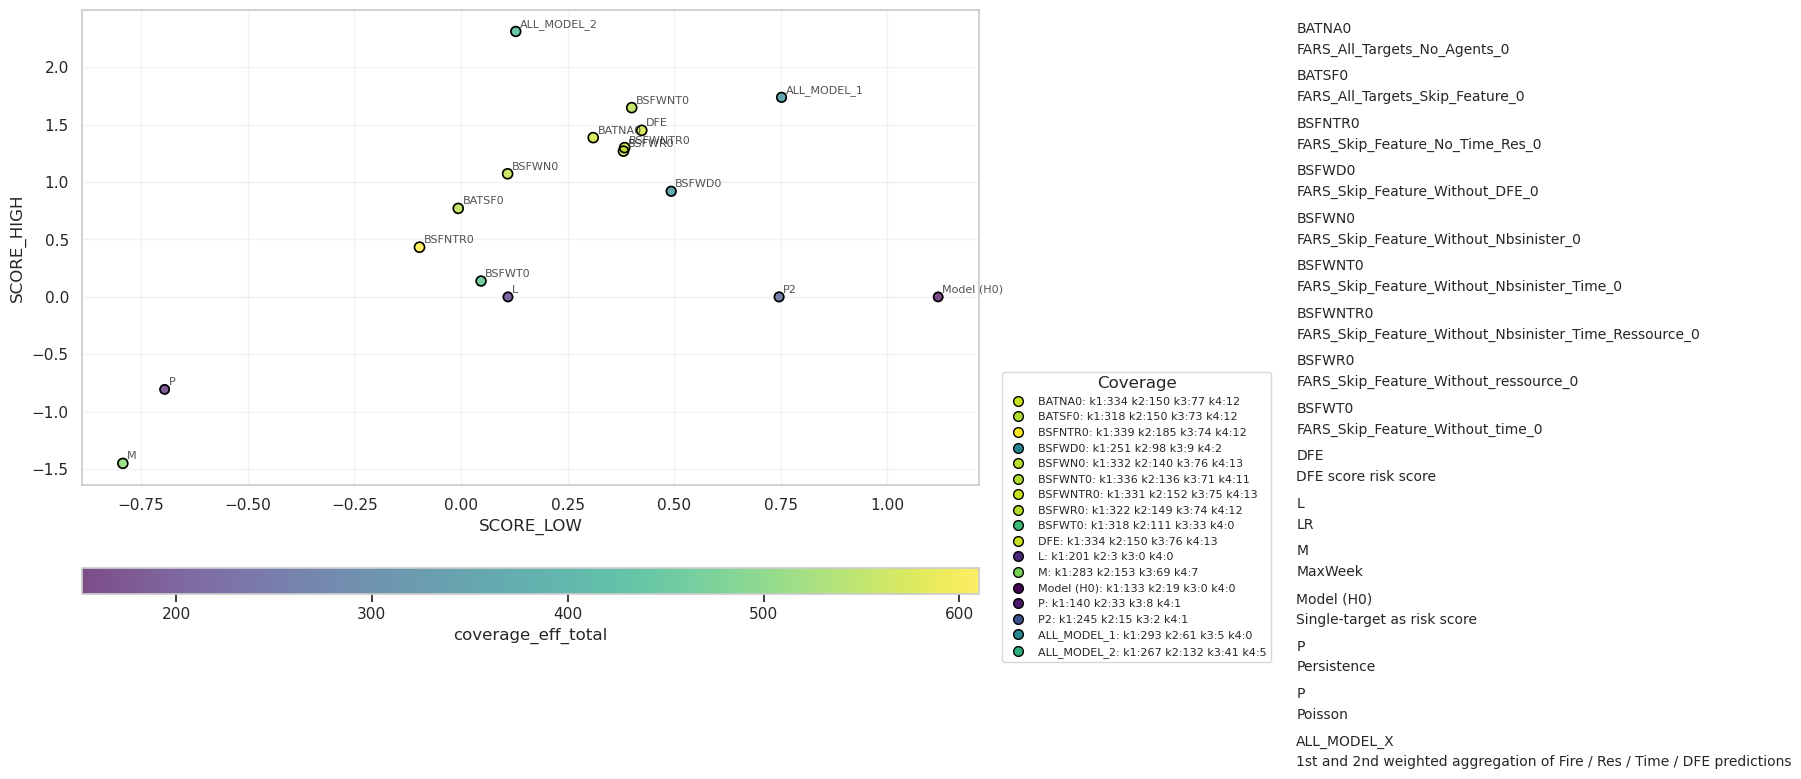


Top-2 aggregation configs retenues :
   All Model (H0)_0_w0.00-0.00-1.00_dfe0.50_norm
   All Model (H0)_3_w1.00-0.00-0.00_dfe1.00_norm
\begin{table}[ht]
\centering
\begin{tabular}{lrrrrrrr}
\hline
config & SCORE_LOW & SCORE_HIGH & Coverage & SCORE_k1 & SCORE_k2 & SCORE_k3 & SCORE_k4 \\
\hline
All Model (H0)\_0\_w0.00-0.00-1.00\_dfe0.50\_norm & 0.75 & 1.74 & k1:293 k2:61 k3:5 k4:0 & 0.11 & 0.64 & 1.74 & - \\
All Model (H0)\_3\_w1.00-0.00-0.00\_dfe1.00\_norm & 0.13 & 2.31 & k1:267 k2:132 k3:41 k4:5 & 0.04 & 0.09 & 0.53 & 1.78 \\
Bulletin\_Skip\_Feature\_Without\_Nbsinister\_Time\_0 & 0.40 & 1.65 & k1:336 k2:136 k3:71 k4:11 & 0.12 & 0.28 & 0.63 & 1.02 \\
DFE\_score & 0.42 & 1.45 & k1:334 k2:150 k3:76 k4:13 & 0.09 & 0.33 & 0.56 & 0.89 \\
Bulletin\_All\_Targets\_No\_Agents\_0 & 0.31 & 1.39 & k1:334 k2:150 k3:77 k4:12 & 0.06 & 0.25 & 0.53 & 0.86 \\
Bulletin\_Skip\_Feature\_Without\_Nbsinister\_Time\_Ressource\_0 & 0.38 & 1.30 & k1:331 k2:152 k3:75 k4:13 & 0.12 & 0.27 & 0.51 & 0.79 \\
Bullet

In [ ]:
# -----------------------------
# Spline FE: mu(0..4) + passages (avec 4)
# -----------------------------
LEVELS = [0, 1, 2, 3, 4]

PASSAGES = {
    1: [(0,1), (1,2), (2,3), (3,4)],
    2: [(0,2), (1,3), (2,4)],
    3: [(0,3), (1,4)],
    4: [(0,4)],
}

TARGETS = {
    #"DFE":  ("dfe_df_filter",  "DFE"),
    "Fire": ("fire_df_filter", "nbsinister"),
    #"Res":  ("res_df_filter",  "ressource"),
    #"Time": ("time_df_filter", "time_intervention"),
}

EXTRAPOLATION = False

# Construct lists including stats models
# Construct lists including stats models (Dynamic)
fire_list = [fire_df_filter]
res_list = [res_df_filter]
time_list = [time_df_filter]
active_names = ["Model (H0)"]

for m in stat_models_names:
    # Only include if nbsinister (primary target) is available
    if 'nbsinister' in stats_results[m]:
            fire_list.append(stats_results[m]['nbsinister'])
            res_list.append(stats_results[m].get('ressource'))
            time_list.append(stats_results[m].get('timeintervention'))
            active_names.append(name_mapping.get(m, m))

results = run_pareto_top2_aggregation(
    model_names=active_names,
    data_frames=data_frames,
    TARGETS=TARGETS,
    apply_normalisation=False,
    dfe_df_filter=dfe_df_filter,
    fire_df_filter=fire_list,
    res_df_filter=res_list,
    time_df_filter=time_list,
    dfe_df=dfe_df_filter,                     # celui utilisé pour DFE_score
    EXTRAPOLATION=EXTRAPOLATION,
    df_spline=5,
    min_n=5,
    agg_prefix="All Model (H0)",      # nom des configs d’agrégation
    keep_baselines=["DFE_score", "Model (H0)"],
    low_ks=(1, 2),
    high_ks=(3, 4),
    size_by="coverage_eff_total",
    color_by="coverage_eff_total",
    title="",
    add_agreggate=True,
    agregate_type="Normal",
    min_gain=[0, 0, 0, 0]
)

print("\nTop-2 aggregation configs retenues :")
for c in results["top2_agg"]:
    print("  ", c)
    
# Si tu veux récupérer les tables pour analyse ensuite :
scores_lh_plot = results["scores_lh_plot"]
coverage_plot  = results["coverage_plot"]
all_metrics    = results["all_metrics"]
print(results['latex'])
latex_fire = results['latex']

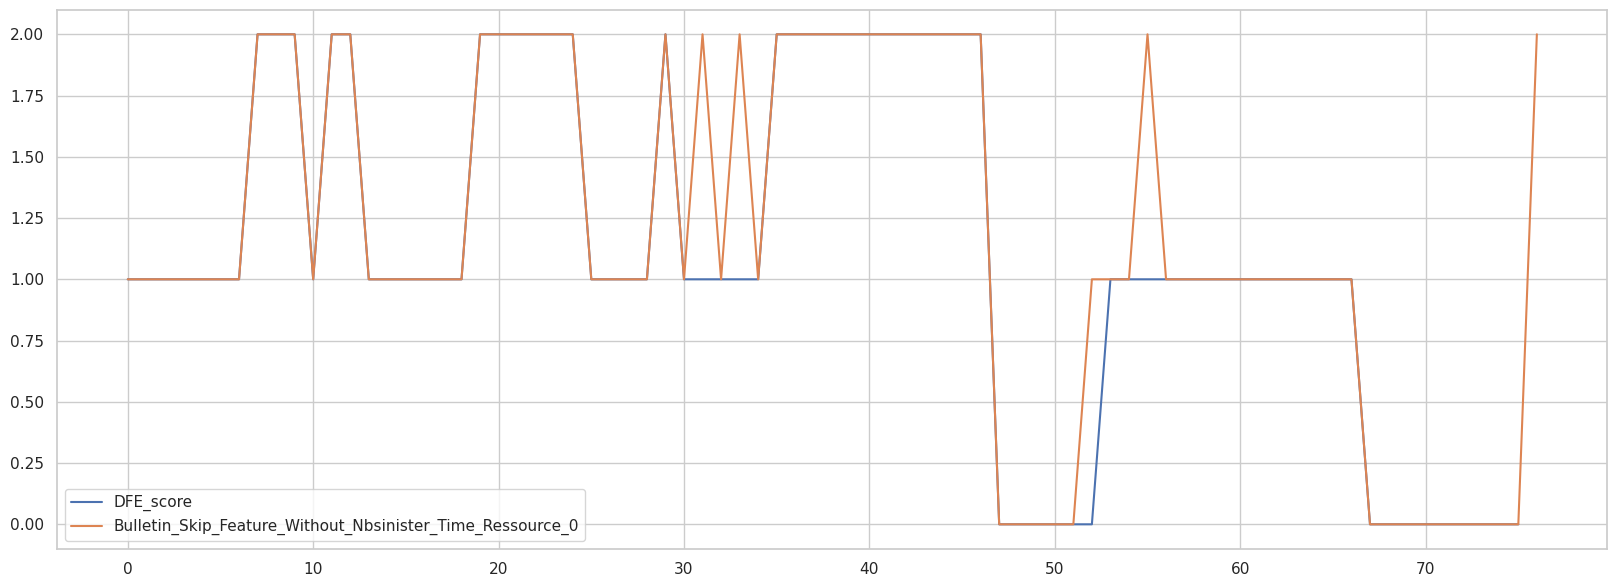

In [34]:
df_long_by_target = results['df_long_by_target']

t = "Fire"
num_zone = 67
cfg_name_a = "DFE_score"
cfg_name_b = "Bulletin_Skip_Feature_Without_Nbsinister_Time_Ressource_0"
cfg_name_c = "Bulletin"

df_target = df_long_by_target[t]

config_a = df_target[df_target['config'] == cfg_name_a]
config_a = config_a[config_a['num_zone'] == num_zone]

config_b = df_target[df_target['config'] == cfg_name_b]
config_b = config_b[config_b['num_zone'] == num_zone]

config_c = df_target[df_target['config'] == cfg_name_c]
config_c = config_c[config_c['num_zone'] == num_zone]

values =  config_a['Y'].values

if t in ['Time', 'Res']:
    values = np.sqrt(values)
    
plt.figure(figsize=(20,7))
plt.plot(config_a['score'].reset_index(drop=True), label=cfg_name_a)
plt.plot(config_b['score'].reset_index(drop=True), label=cfg_name_b)
#plt.plot(config_c['score'].reset_index(drop=True), label=cfg_name_c)
#plt.plot(values, label=t)
plt.legend()
plt.show()

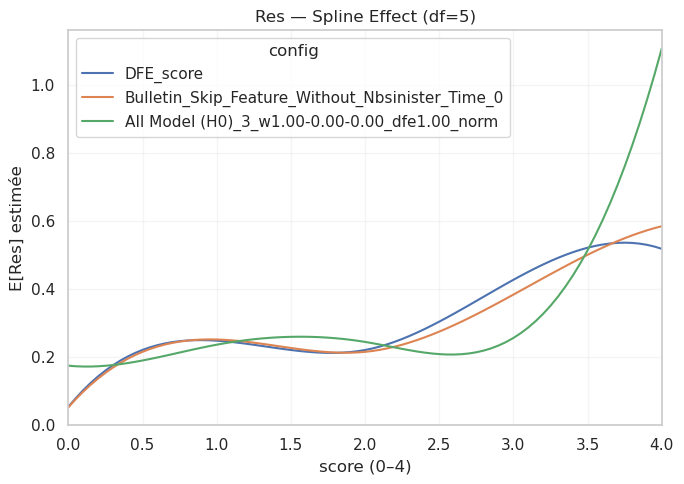

{'DFE_score': <statsmodels.regression.linear_model.RegressionResultsWrapper at 0x764db020bdd0>,
 'Bulletin_Skip_Feature_Without_Nbsinister_Time_0': <statsmodels.regression.linear_model.RegressionResultsWrapper at 0x764db0230fb0>,
 'All Model (H0)_3_w1.00-0.00-0.00_dfe1.00_norm': <statsmodels.regression.linear_model.RegressionResultsWrapper at 0x764db0295190>}

In [35]:
plot_spline_effect_for_target_multi(df_long_by_target["Fire"], ['DFE_score', 'Bulletin_Skip_Feature_Without_Nbsinister_Time_0', 'All Model (H0)_3_w1.00-0.00-0.00_dfe1.00_norm'], "Res", df_spline=5)

In [36]:
fire_df_filter['nbsinister'].max()

3.0

/tmp/ipykernel_534709/657606242.py:91: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df_long = pd.concat(parts, ignore_index=True)
/tmp/ipykernel_534709/657606242.py:91: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df_long = pd.concat(parts, ignore_index=True)
/tmp/ipykernel_534709/657606242.py:91: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result

All Model (H0)_0_w0.00-0.00-1.00_dfe0.00_norm
1 [0.37291958 0.8227223 ] 2 0.5978209397792195 0.37291957530216413 0.0 0.0
2 [1.19564188] 1 1.195641879558439 1.195641879558439 0.0 0.0
3 [] 0 nan nan nan nan
4 [] 0 nan nan nan nan
All Model (H0)_0_w0.00-0.00-1.00_dfe0.25_norm
1 [-0.18306411  1.00520585] 2 0.4110708723778857 -0.18306410600355305 0.5 0.09153205300177653
2 [0.82214174] 1 0.8221417447557715 0.8221417447557715 0.0 0.0
3 [] 0 nan nan nan nan
4 [] 0 nan nan nan nan
All Model (H0)_0_w0.00-0.00-1.00_dfe0.50_norm
1 [0.09934311 0.70809873 3.22059096] 3 0.7080987257508211 0.09934311082321734 0.0 0.0
2 [0.80744184 3.92868968] 2 2.3680657601892747 0.8074418365740385 0.0 0.0
3 [4.02803279] 1 4.028032794627729 4.028032794627729 0.0 0.0
4 [] 0 nan nan nan nan
All Model (H0)_0_w0.00-0.00-1.00_dfe1.00_norm
1 [-0.13259894  0.16997009  3.53917563] 3 0.1699700944287459 -0.13259894058325128 0.3333333333333333 0.04419964686108376
2 [0.03737115 3.40657669] 2 1.7219739223260437 0.03737115384549461

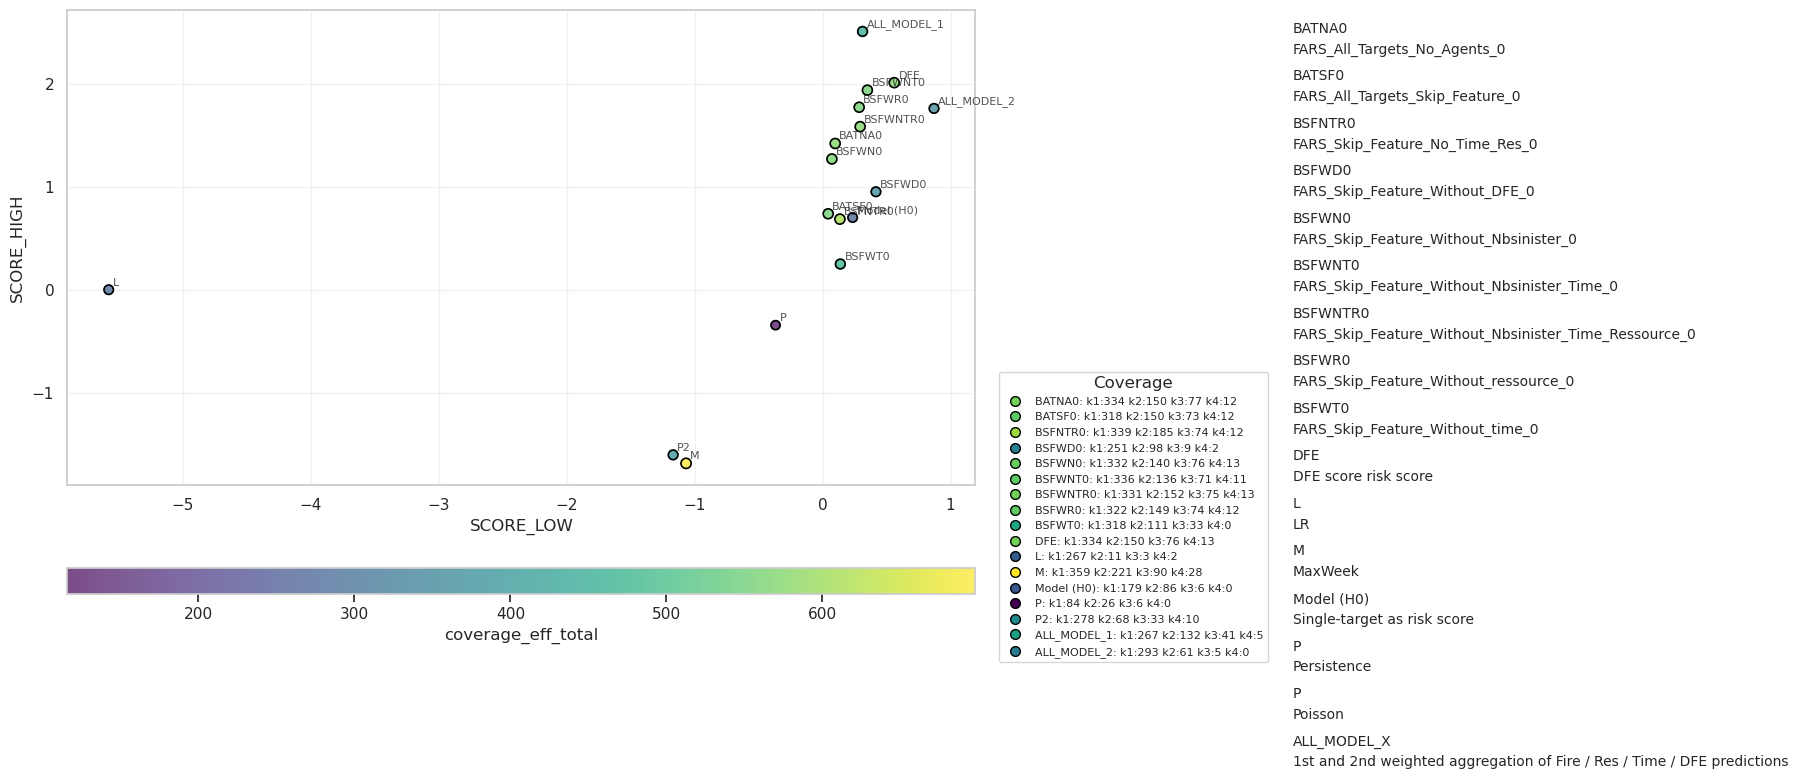


Top-2 aggregation configs retenues :
   All Model (H0)_3_w1.00-0.00-0.00_dfe1.00_norm
   All Model (H0)_0_w0.00-0.00-1.00_dfe0.50_norm
\begin{table}[ht]
\centering
\begin{tabular}{lrrrrrrr}
\hline
config & SCORE_LOW & SCORE_HIGH & Coverage & SCORE_k1 & SCORE_k2 & SCORE_k3 & SCORE_k4 \\
\hline
All Model (H0)\_3\_w1.00-0.00-0.00\_dfe1.00\_norm & 0.31 & 2.51 & k1:267 k2:132 k3:41 k4:5 & 0.10 & 0.21 & 0.74 & 1.77 \\
All Model (H0)\_0\_w0.00-0.00-1.00\_dfe0.50\_norm & 0.87 & 1.76 & k1:293 k2:61 k3:5 k4:0 & 0.18 & 0.69 & 1.76 & - \\
DFE\_score & 0.56 & 2.01 & k1:334 k2:150 k3:76 k4:13 & 0.19 & 0.37 & 0.73 & 1.29 \\
Bulletin\_Skip\_Feature\_Without\_Nbsinister\_Time\_0 & 0.35 & 1.94 & k1:336 k2:136 k3:71 k4:11 & 0.12 & 0.23 & 0.60 & 1.33 \\
Bulletin\_Skip\_Feature\_Without\_ressource\_0 & 0.29 & 1.77 & k1:322 k2:149 k3:74 k4:12 & 0.10 & 0.19 & 0.54 & 1.23 \\
Bulletin\_Skip\_Feature\_Without\_Nbsinister\_Time\_Ressource\_0 & 0.29 & 1.58 & k1:331 k2:152 k3:75 k4:13 & 0.09 & 0.20 & 0.52 & 1.06 

In [37]:

# -----------------------------
# Spline FE: mu(0..4) + passages (avec 4)
# -----------------------------
LEVELS = [0, 1, 2, 3, 4]

PASSAGES = {
    1: [(0,1), (1,2), (2,3), (3,4)],
    2: [(0,2), (1,3), (2,4)],
    3: [(0,3), (1,4)],
    4: [(0,4)],
}

TARGETS = { 
    #"DFE":  ("dfe_df_filter",  "DFE"),
    #"Fire": ("fire_df_filter", "nbsinister"),
    "Res":  ("res_df_filter",  "ressource"),
    #"Time": ("time_df_filter", "time_intervention"),
}

EXTRAPOLATION = False

# Construct lists including stats models
# Construct lists including stats models (Dynamic)
fire_list = [fire_df_filter]
res_list = [res_df_filter]
time_list = [time_df_filter]
active_names = ["Model (H0)"]

for m in stat_models_names:
    # Only include if nbsinister (primary target) is available
    if 'nbsinister' in stats_results[m]:
            fire_list.append(stats_results[m]['nbsinister'])
            res_list.append(stats_results[m].get('ressource'))
            time_list.append(stats_results[m].get('timeintervention'))
            active_names.append(name_mapping.get(m, m))


results = run_pareto_top2_aggregation(
model_names=active_names,
data_frames=data_frames,
TARGETS=TARGETS,
dfe_df_filter=dfe_df_filter,
fire_df_filter=fire_list,
res_df_filter=res_list,
apply_normalisation=False,
time_df_filter=time_list,
dfe_df=dfe_df_filter,                     # celui utilisé pour DFE_score
EXTRAPOLATION=EXTRAPOLATION,
df_spline=5,
min_n=5,
agg_prefix="All Model (H0)",      # nom des configs d’agrégation
keep_baselines=["DFE_score", "Model (H0)"],
low_ks=(1, 2),
high_ks=(3, 4),
size_by="coverage_eff_total",
color_by="coverage_eff_total",
title="",
add_agreggate=True,
agregate_type='Normal',
min_gain=[0, 0, 0, 0]
)

print("\nTop-2 aggregation configs retenues :")
for c in results["top2_agg"]:
    print("  ", c)
    
# Si tu veux récupérer les tables pour analyse ensuite :
scores_lh_plot = results["scores_lh_plot"]
coverage_plot  = results["coverage_plot"]
all_metrics    = results["all_metrics"]
print(results['latex'])

latex_res = results['latex']

In [38]:
#boostrap(TARGETS)

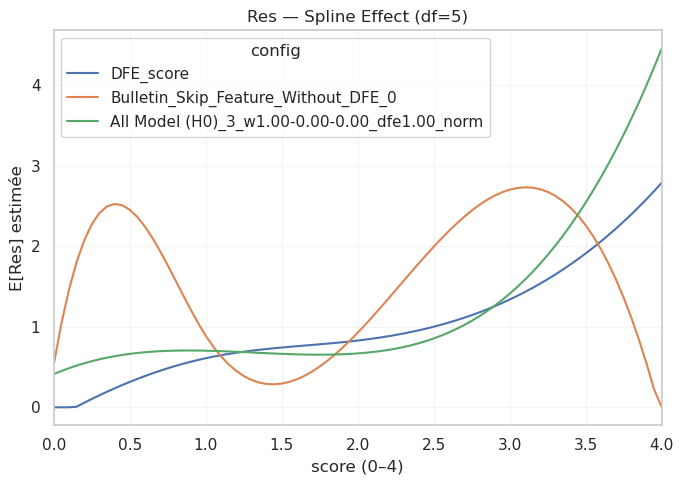

{'DFE_score': <statsmodels.regression.linear_model.RegressionResultsWrapper at 0x764db220b290>,
 'Bulletin_Skip_Feature_Without_DFE_0': <statsmodels.regression.linear_model.RegressionResultsWrapper at 0x764db5536210>,
 'All Model (H0)_3_w1.00-0.00-0.00_dfe1.00_norm': <statsmodels.regression.linear_model.RegressionResultsWrapper at 0x764db1a1a930>}

In [39]:
df_long_by_target = results['df_long_by_target']

plot_spline_effect_for_target_multi(df_long_by_target["Res"], ['DFE_score', 'Bulletin_Skip_Feature_Without_DFE_0', 'All Model (H0)_3_w1.00-0.00-0.00_dfe1.00_norm'], "Res", df_spline=5)

/tmp/ipykernel_534709/657606242.py:91: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df_long = pd.concat(parts, ignore_index=True)
/tmp/ipykernel_534709/657606242.py:91: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df_long = pd.concat(parts, ignore_index=True)
/tmp/ipykernel_534709/657606242.py:91: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result

All Model (H0)_0_w0.00-0.00-1.00_dfe0.00_norm
1 [ 6.51668438 17.04384609] 2 11.780265234186539 6.516684378851359 0.0 0.0
2 [23.56053047] 1 23.560530468373077 23.560530468373077 0.0 0.0
3 [] 0 nan nan nan nan
4 [] 0 nan nan nan nan
All Model (H0)_0_w0.00-0.00-1.00_dfe0.25_norm
1 [-3.22437254 16.80903378] 2 6.792330621319698 -3.2243725396268523 0.5 1.6121862698134262
2 [13.58466124] 1 13.584661242639395 13.584661242639395 0.0 0.0
3 [] 0 nan nan nan nan
4 [] 0 nan nan nan nan
All Model (H0)_0_w0.00-0.00-1.00_dfe0.50_norm
1 [ 5.94550689  7.83417777 14.16155402] 3 7.834177766542169 5.945506894951286 0.0 0.0
2 [20.10706092 21.99573179] 2 21.051396353822756 20.107060918027315 0.0 0.0
3 [27.94123868] 1 27.941238684569484 27.941238684569484 0.0 0.0
4 [] 0 nan nan nan nan
All Model (H0)_0_w0.00-0.00-1.00_dfe1.00_norm
1 [-10.43663202  10.07492967  12.98631798] 3 10.074929666181784 -10.436632022022081 0.3333333333333333 3.478877340674027
2 [-0.36170236  2.54968595] 2 1.093991798694292 -0.361702355

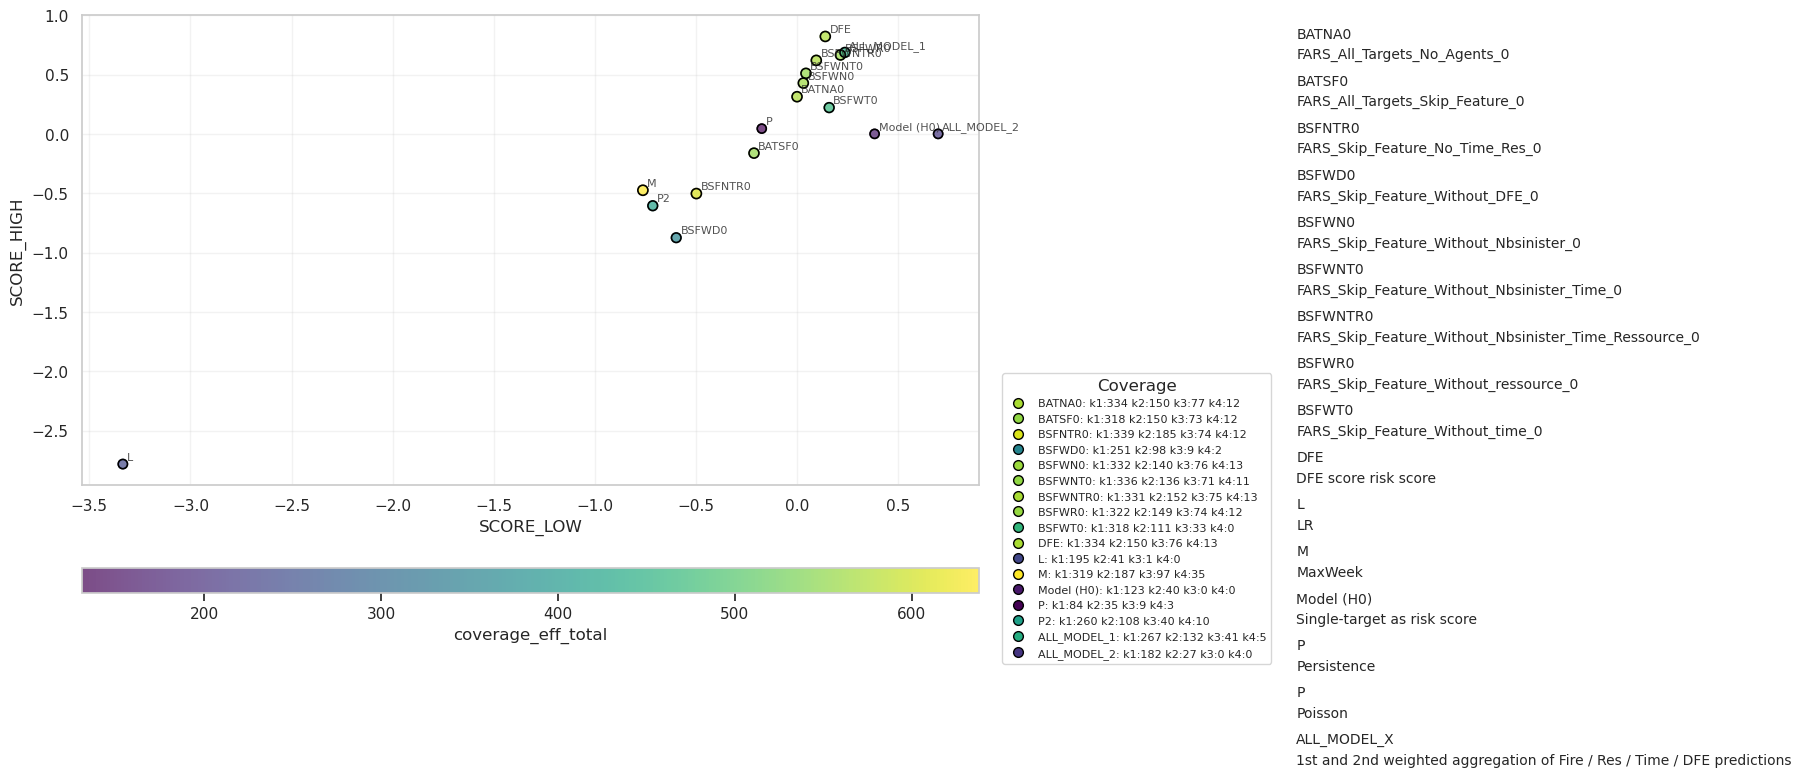


Top-2 aggregation configs retenues :
   All Model (H0)_3_w1.00-0.00-0.00_dfe1.00_norm
   All Model (H0)_0_w0.75-0.00-0.25_dfe0.25_norm
\begin{table}[ht]
\centering
\begin{tabular}{lrrrrrrr}
\hline
config & SCORE_LOW & SCORE_HIGH & Coverage & SCORE_k1 & SCORE_k2 & SCORE_k3 & SCORE_k4 \\
\hline
DFE\_score & 0.14 & 0.82 & k1:334 k2:150 k3:76 k4:13 & -0.03 & 0.17 & 0.28 & 0.54 \\
All Model (H0)\_3\_w1.00-0.00-0.00\_dfe1.00\_norm & 0.24 & 0.69 & k1:267 k2:132 k3:41 k4:5 & 0.07 & 0.17 & 0.26 & 0.43 \\
Bulletin\_Skip\_Feature\_Without\_ressource\_0 & 0.22 & 0.66 & k1:322 k2:149 k3:74 k4:12 & 0.06 & 0.16 & 0.25 & 0.42 \\
Bulletin\_Skip\_Feature\_Without\_Nbsinister\_Time\_Ressource\_0 & 0.10 & 0.62 & k1:331 k2:152 k3:75 k4:13 & -0.04 & 0.13 & 0.20 & 0.42 \\
All Model (H0)\_0\_w0.75-0.00-0.25\_dfe0.25\_norm & 0.70 & 0.00 & k1:182 k2:27 k3:0 k4:0 & 0.16 & 0.54 & - & - \\
Bulletin\_Skip\_Feature\_Without\_Nbsinister\_Time\_0 & 0.05 & 0.51 & k1:336 k2:136 k3:71 k4:11 & -0.06 & 0.11 & 0.15 & 0.36 

In [ ]:
# ============================================================
# RUN (top-2 aggregation Pareto)
# ============================================================

LEVELS = [0, 1, 2, 3, 4]
PASSAGES = { 1: [(0,1), (1,2), (2,3), (3,4)], 2: [(0,2), (1,3), (2,4)], 3: [(0,3), (1,4)], 4: [(0,4)], }
EXTRAPOLATION = False

TARGETS = {
    #"DFE":  ("dfe_df_filter",  "DFE"),
    #"Fire": ("fire_df_filter", "nbsinister"),
    #"Res":  ("res_df_filter",  "ressource"),
    "Time": ("time_df_filter", "time_intervention"),
}

# Construct lists including stats models
# Construct lists including stats models (Dynamic)
fire_list = [fire_df_filter]
res_list = [res_df_filter]
time_list = [time_df_filter]
active_names = ["Model (H0)"]

for m in stat_models_names:
    # Only include if nbsinister (primary target) is available
    if 'nbsinister' in stats_results[m]:
            fire_list.append(stats_results[m]['nbsinister'])
            res_list.append(stats_results[m].get('ressource'))
            time_list.append(stats_results[m].get('timeintervention'))
            active_names.append(name_mapping.get(m, m))


results = run_pareto_top2_aggregation(
model_names=active_names,
data_frames=data_frames,
TARGETS=TARGETS,
dfe_df_filter=dfe_df_filter,
fire_df_filter=fire_list,
res_df_filter=res_list,
time_df_filter=time_list,
dfe_df=dfe_df,                     # celui utilisé pour DFE_score
EXTRAPOLATION=EXTRAPOLATION,
df_spline=5,
min_n=1,
agg_prefix="All Model (H0)",      # nom des configs d’agrégation
keep_baselines=["DFE_score", "Model (H0)"],
low_ks=(1, 2),
high_ks=(3, 4),
size_by="coverage_eff_total",
color_by="coverage_eff_total",
title="",
agregate_type='Normal',
add_agreggate=True,
min_gain=[0, 0, 0, 0]
)

print("\nTop-2 aggregation configs retenues :")
for c in results["top2_agg"]:
    print("  ", c)
    
# Si tu veux récupérer les tables pour analyse ensuite :
scores_lh_plot = results["scores_lh_plot"]
coverage_plot  = results["coverage_plot"]
all_metrics    = results["all_metrics"]

print(results['latex'])
latex_time = results['latex']

In [41]:
#boostrap(TARGETS)

In [42]:
try:
    from xgboost import DMatrix
except ImportError:
    class DMatrix:
        def __init__(self, data, label=None):
            self.data = data
            self.label = label
        def get_data(self):
            return self.data
        def get_label(self):
            return self.label
        
def iou_score(y_true, y_pred):
    """Calcule l'indice IoU entre deux signaux continus.

    Parameters
    ----------
    y_true : np.ndarray | DMatrix
        Signal de référence (vérité terrain).
    y_pred : np.ndarray | DMatrix
        Signal prédit (à comparer au signal de référence).

    Returns
    -------
    float
        Valeur IoU (aire d'intersection divisée par aire d'union).
    """

    if isinstance(y_pred, DMatrix):
        y_pred = np.copy(y_pred.get_data().toarray())

    if isinstance(y_true, DMatrix):
        y_true = np.copy(y_true.get_label())

    y_pred = np.reshape(y_pred, y_true.shape)
    # Calcul des différentes aires
    intersection = np.trapz(np.minimum(y_pred, y_true))  # Aire commune
    union = np.trapz(np.maximum(y_pred, y_true))         # Aire d'union

    return intersection / union if union > 0 else 0

In [43]:
fire_df_filter.nbsinister.unique()
df_long_by_target = results['df_long_by_target']

In [44]:
config_a.date.unique()

<DatetimeArray>
['2023-07-11 00:00:00', '2023-07-12 00:00:00', '2023-07-13 00:00:00',
 '2023-07-14 00:00:00', '2023-07-15 00:00:00', '2023-07-16 00:00:00',
 '2023-07-17 00:00:00', '2023-07-18 00:00:00', '2023-07-19 00:00:00',
 '2023-07-20 00:00:00', '2023-07-21 00:00:00', '2023-07-22 00:00:00',
 '2023-07-23 00:00:00', '2023-07-24 00:00:00', '2023-07-25 00:00:00',
 '2023-07-26 00:00:00', '2023-07-27 00:00:00', '2023-07-28 00:00:00',
 '2023-07-29 00:00:00', '2023-07-30 00:00:00', '2023-07-31 00:00:00',
 '2023-08-01 00:00:00', '2023-08-02 00:00:00', '2023-08-03 00:00:00',
 '2023-08-04 00:00:00', '2023-08-05 00:00:00', '2023-08-06 00:00:00',
 '2023-08-07 00:00:00', '2023-08-08 00:00:00', '2023-08-09 00:00:00',
 '2023-08-10 00:00:00', '2023-08-11 00:00:00', '2023-08-12 00:00:00',
 '2023-08-13 00:00:00', '2023-08-14 00:00:00', '2023-08-15 00:00:00',
 '2023-08-16 00:00:00', '2023-08-17 00:00:00', '2023-08-18 00:00:00',
 '2023-08-19 00:00:00', '2023-08-20 00:00:00', '2023-08-21 00:00:00',
 '20

In [45]:
config_a.drop_duplicates('date')

,date,num_zone,config,score,Y
39877,2023-07-11,67,DFE_score,1.0,0.0
39878,2023-07-12,67,DFE_score,1.0,0.0
39879,2023-07-13,67,DFE_score,1.0,0.0
39880,2023-07-14,67,DFE_score,1.0,0.0
39881,2023-07-15,67,DFE_score,1.0,0.0
...,...,...,...,...,...
39948,2023-09-20,67,DFE_score,0.0,0.0
39949,2023-09-21,67,DFE_score,0.0,0.0
39950,2023-09-22,67,DFE_score,0.0,0.0
39951,2023-09-23,67,DFE_score,0.0,0.0


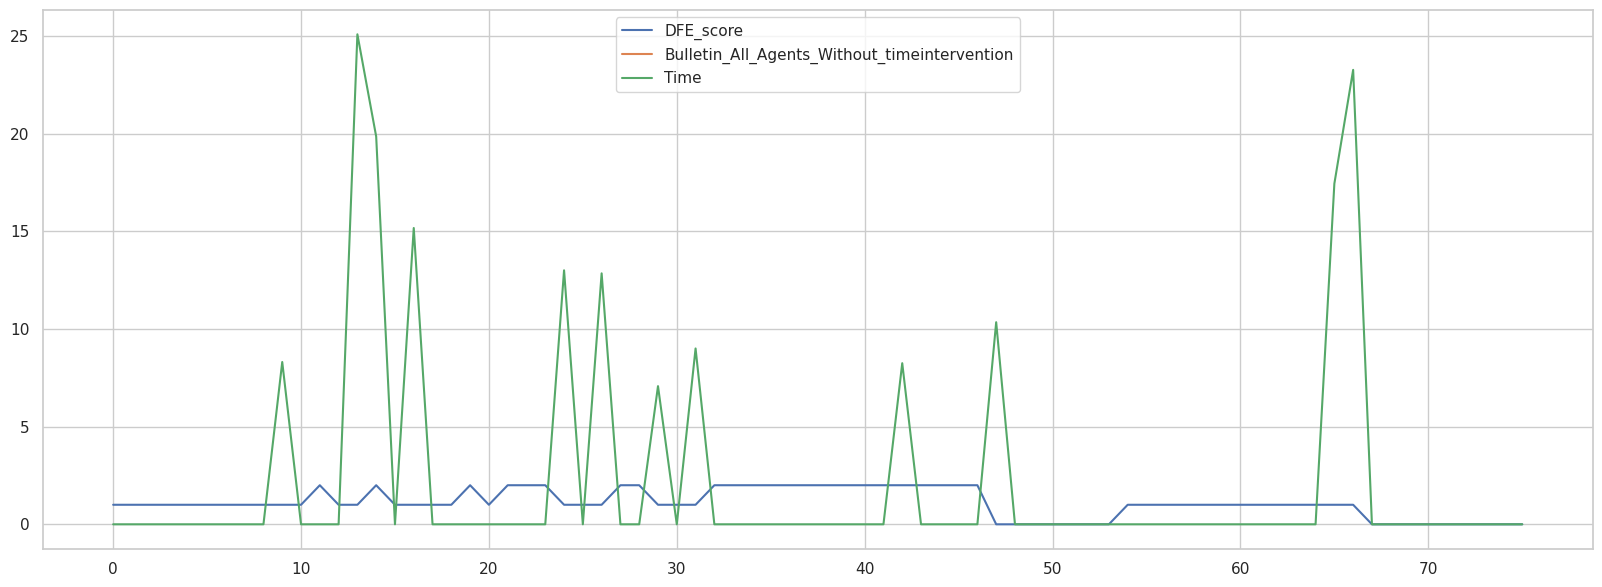

In [46]:
t = "Time"
num_zone = 62
cfg_name_a = "DFE_score"
cfg_name_b = "Bulletin_All_Agents_Without_timeintervention"
cfg_name_c = "Bulletin"

df_target = df_long_by_target[t]

config_a = df_target[df_target['config'] == cfg_name_a]
config_a = config_a[config_a['num_zone'] == num_zone]

config_b = df_target[df_target['config'] == cfg_name_b]
config_b = config_b[config_b['num_zone'] == num_zone]

config_c = df_target[df_target['config'] == cfg_name_c]
config_c = config_c[config_c['num_zone'] == num_zone]

values =  config_a['Y'].values

if t in ['Time', 'Res']:
    values = np.sqrt(values)
    
plt.figure(figsize=(20,7))
plt.plot(config_a['score'].reset_index(drop=True), label=cfg_name_a)
plt.plot(config_b['score'].reset_index(drop=True), label=cfg_name_b)
#plt.plot(config_c['score'].reset_index(drop=True), label=cfg_name_c)
plt.plot(values, label=t)
plt.legend()
plt.show()

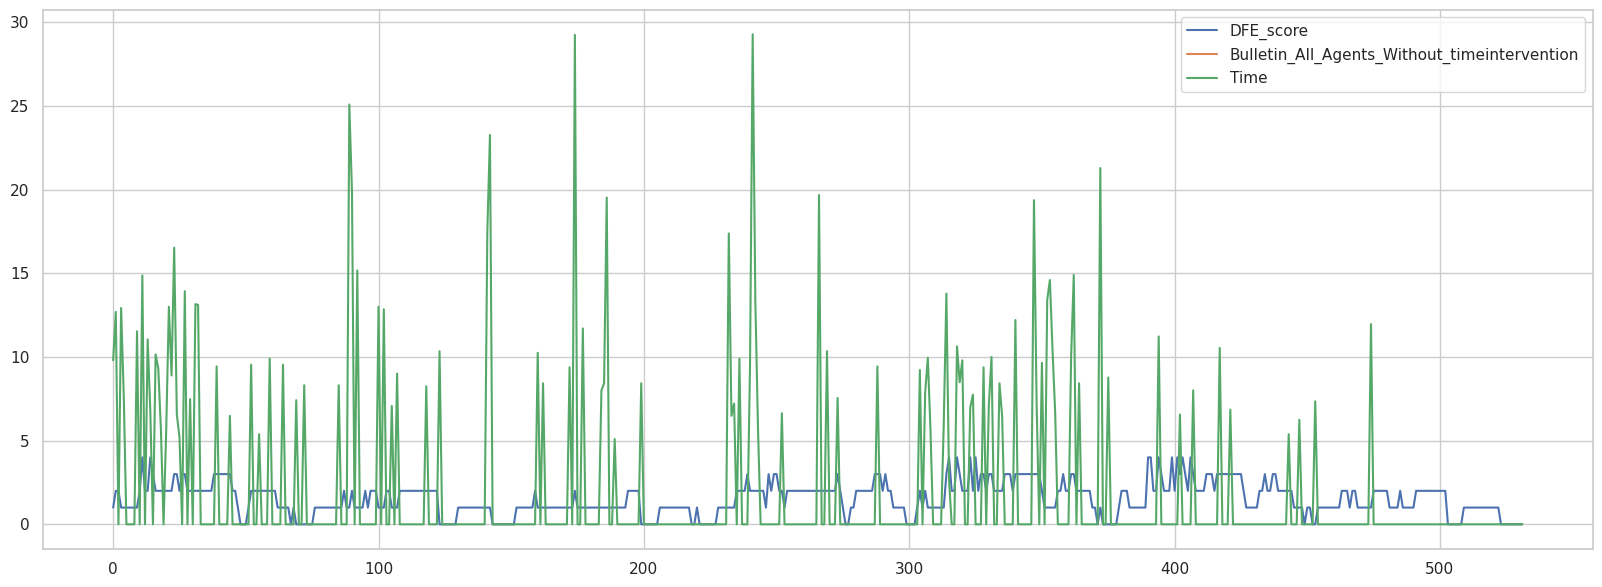

In [47]:
t = "Time"
cfg_name_a = "DFE_score"
cfg_name_b = "Bulletin_All_Agents_Without_timeintervention"
cfg_name_c = "Bulletin"

df_target = df_long_by_target[t]

config_a = df_target[df_target['config'] == cfg_name_a]

config_b = df_target[df_target['config'] == cfg_name_b]

config_c = df_target[df_target['config'] == cfg_name_c]

values =  config_a['Y'].values

if t in ['Time', 'Res']:
    values = np.sqrt(values)
    
plt.figure(figsize=(20,7))
plt.plot(config_a['score'].reset_index(drop=True), label=cfg_name_a)
plt.plot(config_b['score'].reset_index(drop=True), label=cfg_name_b)
#plt.plot(config_c['score'].reset_index(drop=True), label=cfg_name_c)
plt.plot(values, label=t)
plt.legend()
plt.show()

In [48]:
df_long_by_target['Time'].config

0            Bulletin_Skip_Feature_Without_Nbsinister_0
1            Bulletin_Skip_Feature_Without_Nbsinister_0
2            Bulletin_Skip_Feature_Without_Nbsinister_0
3            Bulletin_Skip_Feature_Without_Nbsinister_0
4            Bulletin_Skip_Feature_Without_Nbsinister_0
                              ...                      
178204    All Model (H0)_4_w0.33-0.33-0.33_dfe1.00_norm
178205    All Model (H0)_4_w0.33-0.33-0.33_dfe1.00_norm
178206    All Model (H0)_4_w0.33-0.33-0.33_dfe1.00_norm
178207    All Model (H0)_4_w0.33-0.33-0.33_dfe1.00_norm
178208    All Model (H0)_4_w0.33-0.33-0.33_dfe1.00_norm
Name: config, Length: 178209, dtype: object

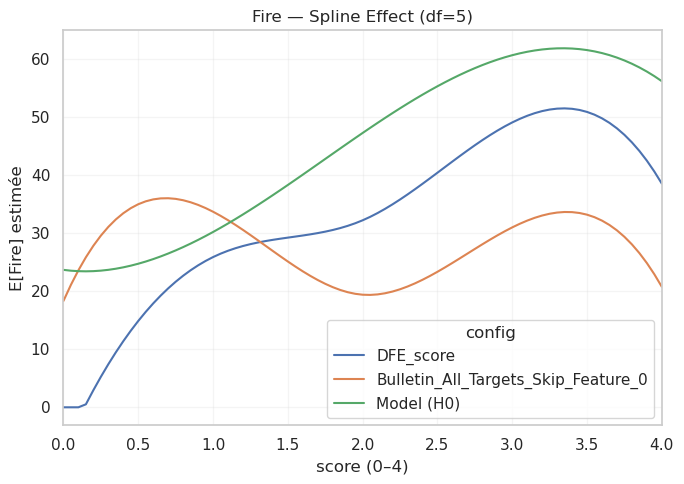

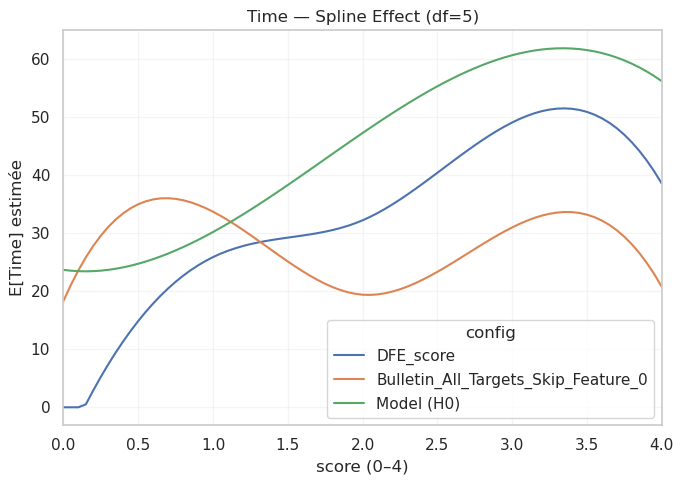

{'DFE_score': <statsmodels.regression.linear_model.RegressionResultsWrapper at 0x764db77bb710>,
 'Bulletin_All_Targets_Skip_Feature_0': <statsmodels.regression.linear_model.RegressionResultsWrapper at 0x764db780bd70>,
 'Model (H0)': <statsmodels.regression.linear_model.RegressionResultsWrapper at 0x764db4ab3c50>}

In [49]:
plot_spline_effect_for_target_multi(df_long_by_target["Time"], ['DFE_score', 'Bulletin_All_Targets_Skip_Feature_0', 'Model (H0)'], "Fire", df_spline=5)
plot_spline_effect_for_target_multi(df_long_by_target["Time"], ['DFE_score', 'Bulletin_All_Targets_Skip_Feature_0', 'Model (H0)'], "Time", df_spline=5)

In [50]:
dfe_df_filter.shape

(532, 127)

In [51]:

import json
import glob
import pandas as pd
import numpy as np
import os
from sklearn.metrics import f1_score, mean_absolute_error, jaccard_score, recall_score, precision_score

def load_bulletin_predictions(base_dir):
    """
    Loads Bulletin predictions from JSON files.
    """
    json_files = glob.glob(os.path.join(base_dir, "bulletin_*.json"))
    data = []
    
    risk_mapping = {
        "Faible": 1,
        "Moyen": 2,
        "Elevé": 3,
        "Très Elevé": 4,
        "Extrême": 5,
        "Très extrême": 5 # Handle potential variations
    }

    for file_path in json_files:
        try:
            with open(file_path, 'r') as f:
                content = json.load(f)
                
            # Extract date from filename
            date_str = os.path.basename(file_path).replace("bulletin_", "").replace(".json", "")
            
            for entry in content.get("output", []):
                risk_level = entry.get("niveau_risque")
                risk_score = risk_mapping.get(risk_level, 0) # Default to 0 if unknown
                
                data.append({
                    "date": date_str,
                    "num_zone": entry.get("num_zone"),
                    "prediction_Bulletin": risk_score
                })
        except Exception as e:
            print(f"Error loading {file_path}: {e}")

    df = pd.DataFrame(data)
    if not df.empty:
        df['date'] = pd.to_datetime(df['date'])
    return df

def calculate_metrics(y_true, y_pred, thresholds=None):
    """
    Calculates MAE, IoU, Macro F1, and Binary F1 (optional thresholds).
    """
    metrics = {}
    
    # Ensure numpy arrays
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    
    # Drop NaNs
    mask = ~np.isnan(y_true) & ~np.isnan(y_pred)
    y_true = y_true[mask]
    y_pred = y_pred[mask]
    
    if len(y_true) == 0:
        return {"MAE": -1, "IoU": -1, "F1_Macro": -1, "N": 0}

    metrics["N"] = len(y_true)

    # Ensure integer types for classification metrics
    y_true_int = y_true.astype(int)
    y_pred_int = y_pred.astype(int)
    
    # MAE
    metrics["MAE"] = mean_absolute_error(y_true, y_pred)
    
    # IoU (Jaccard) - Macro average
    metrics["IoU"] = jaccard_score(y_true_int, y_pred_int, average='macro', zero_division=0)
    
    # Macro F1
    metrics["F1_Macro"] = f1_score(y_true_int, y_pred_int, average='macro', zero_division=0)
    
    # Binary F1
    if thresholds:
        for t in thresholds:
            # Target is always > 0 (Presence of fire)
            y_true_bin_fixed = (y_true > 0).astype(int) 
            
            # Prediction is > t
            y_pred_bin = (y_pred > t).astype(int)
            
            metrics[f"F1_Binary_>{t}"] = f1_score(y_true_bin_fixed, y_pred_bin, zero_division=0)
            metrics[f"Rec_>{t}"] = recall_score(y_true_bin_fixed, y_pred_bin, zero_division=0)
            metrics[f"Prec_>{t}"] = precision_score(y_true_bin_fixed, y_pred_bin, zero_division=0)
    else:
        # Default Binary F1 (Threshold > 0)
        y_true_bin = (y_true > 0).astype(int)
        y_pred_bin = (y_pred > 0).astype(int)
        metrics["F1_Binary"] = f1_score(y_true_bin, y_pred_bin, zero_division=0)
        
    return metrics

def run_comparison_analysis(data_frames, fire_df, res_df, time_df, dfe_df, stats_results=None):
    # Load Bulletin Data
    # Assuming the path is relative to where the notebook is running

    # Prepare Results Storage
    results_list = []

    # Configs to evaluate
    configs = {
        "Model": {
            "nbsinister": fire_df,
            "ressource": res_df,
            "timeintervention": time_df
        },
        "DFE": {
            "all": dfe_df 
        },
        
    }
    
    configs.update(data_frames)
    
    # Add stats_results configs if available
    if stats_results:
        for model_name, model_data in stats_results.items():
            # stats_results structure seems to be {model_name: {'nbsinister': df, ...}}
            # We treat them similar to "Model" config but they might only have nbsinister
            configs[model_name] = model_data

    # Targets to evaluate against (Ground Truth)
    targets_mapping = {
        "nbsinister": "nbsinister-quantile-5-Class-Dept",
        "ressource": "ressource-quantile-5-Class-Dept",
        "timeintervention": "timeintervention-quantile-5-Class-Dept"
    }

    # Iterate
    for config_name, config_data in configs.items():
        for target_name, target_col in targets_mapping.items():
            
            # 1. Get Ground Truth and Predictions
            if config_name == "Model":
                if target_name not in config_data: continue
                df = config_data[target_name]
                if target_col not in df.columns: continue
                
                y_true = df[target_col].values
                # Model prediction column
                pred_col = f"prediction_{target_col}_0"
                if pred_col not in df.columns: continue
                y_pred = df[pred_col].values
                
                thresholds = None # Standard Binary F1 for Model ( > 0)
                
            elif config_name == "DFE":
                # Source for GT
                if target_name == "nbsinister": gt_source = fire_df
                elif target_name == "ressource": gt_source = res_df
                elif target_name == "timeintervention": gt_source = time_df
                else: continue
                
                # Source for Pred
                pred_source = dfe_df
                
                # Merge
                merged = pd.merge(gt_source, pred_source[['date', 'num_zone', 'prediction_DFE_0']], 
                                  on=['date', 'num_zone'], how='inner', suffixes=('', '_dfe'))
                
                y_true = merged[target_col].values
                y_pred = merged['prediction_DFE_0'].values
                
                thresholds = [1, 2, 3]
                
            elif "Bulletin" in config_name:
                # GT from gt_source
                if target_name == "nbsinister": gt_source = fire_df
                elif target_name == "ressource": gt_source = res_df
                elif target_name == "timeintervention": gt_source = time_df
                else: continue
                
                pred_source = data_frames[config_name]
                pred_source['date'] = pd.to_datetime(pred_source['date'])
                
                # Merge
                merged = pd.merge(gt_source, pred_source, 
                                  on=['date', 'num_zone'], how='inner')
                
                y_true = merged[target_col].values
                y_pred = merged['risk_score'].values
                
                thresholds = [1, 2, 3]
            
            else: 
                # Handle stats_results models (LR, Persistence, etc.)
                # They are likely structured like "Model" config: dict of dataframes
                # Check if target exists for this model
                if target_name not in config_data: continue
                df = config_data[target_name]
                if df is None: continue
                
                # Check columns
                if target_col not in df.columns: continue
                
                # Prediction column might be different for these models?
                # Usually it is 'prediction_' + target_col + '_0'
                pred_col = f"prediction_{target_col}_0"
                if pred_col not in df.columns: 
                    # Try finding a prediction column
                    possible_preds = [c for c in df.columns if 'prediction' in c]
                    if possible_preds:
                        pred_col = possible_preds[0]
                    else:
                        continue
                
                y_true = df[target_col].values
                y_pred = df[pred_col].values
                
                thresholds = None

            # 2. Calculate Metrics
            # "Le f1 score binaire sera calculé seulement sur nbsinister."
            # "pour les calculer il faut binariser la target > 0, et pour chaque seuil 1 2 3 binariser la prédiction > seuil."
            if target_name == "nbsinister":
                current_thresholds = [1, 2, 3]
            else:
                current_thresholds = None

            metrics = calculate_metrics(y_true, y_pred, current_thresholds)
            
            # 3. Store Results
            row = {
                "Config": config_name,
                "Target": target_name,
                "N": metrics.get("N"),
                "MAE": metrics.get("MAE"),
                "IoU": metrics.get("IoU"),
                "F1_Macro": metrics.get("F1_Macro")
            }
            
            if target_name == "nbsinister":
                # Add specific binary F1s, default to -1 if missing (though calculate_metrics should return them)
                row["F1_Binary_>1"] = metrics.get("F1_Binary_>1", -1)
                row["Rec_>1"] = metrics.get("Rec_>1", -1)
                row["Prec_>1"] = metrics.get("Prec_>1", -1)
                #row["F1_Binary_>2"] = metrics.get("F1_Binary_>2", -1)
                #row["F1_Binary_>3"] = metrics.get("F1_Binary_>3", -1)
            
            results_list.append(row)

    # Create DataFrame
    results_df = pd.DataFrame(results_list)
    
    # Display
    print("Comparison Analysis Results:")
    display(results_df)
    return results_df

# Execute only if variables exist (Notebook context)
# Updated to use _filter variables as requested and stats_results
if 'fire_df_filter' in locals() and 'res_df_filter' in locals() and 'time_df_filter' in locals() and 'dfe_df_filter' in locals():
    stats_res = stats_results if 'stats_results' in locals() else None
    run_comparison_analysis(data_frames, fire_df_filter, res_df_filter, time_df_filter, dfe_df_filter, stats_res)
elif 'fire_df_filter' in globals() and 'res_df_filter' in globals() and 'time_df_filter' in globals() and 'dfe_df_filter' in globals():
    stats_res = stats_results if 'stats_results' in globals() else None
    run_comparison_analysis(data_frames, fire_df_filter, res_df_filter, time_df_filter, dfe_df_filter, stats_res)
else:
    print("Skipping execution: Filtered dataframes not found in current scope (Expected during verification).")


Comparison Analysis Results:


,Config,Target,N,MAE,IoU,F1_Macro,F1_Binary_>1,Rec_>1,Prec_>1
0,Model,nbsinister,532,0.313910,0.264399,0.353660,0.211382,0.125000,0.684211
1,Model,ressource,532,0.616541,0.159601,0.218285,NaN,NaN,NaN
2,Model,timeintervention,532,0.385338,0.197175,0.257643,NaN,NaN,NaN
3,DFE,nbsinister,532,1.355263,0.072408,0.131384,0.367454,0.673077,0.252708
4,DFE,ressource,532,1.385338,0.062178,0.114068,NaN,NaN,NaN
5,DFE,timeintervention,532,1.379699,0.054010,0.099005,NaN,NaN,NaN
6,Bulletin_Skip_Feature_Without_Nbsinister,nbsinister,530,1.384906,0.055664,0.100790,0.367876,0.682692,0.251773
7,Bulletin_Skip_Feature_Without_Nbsinister,ressource,530,1.396226,0.091442,0.165343,NaN,NaN,NaN
8,Bulletin_Skip_Feature_Without_Nbsinister,timeintervention,530,1.401887,0.055716,0.101888,NaN,NaN,NaN
9,Bulletin_Skip_Feature_Without_Nbsinister_Time,nbsinister,532,1.364662,0.057704,0.104540,0.359788,0.653846,0.248175


In [52]:
import re
from collections import defaultdict, OrderedDict

def _extract_tabular_blocks(latex: str):
    # Grab each \begin{tabular}...\end{tabular} block
    return re.findall(r"\\begin\{tabular\}\{.*?\}(.*?)\\end\{tabular\}", latex, flags=re.S)

def _parse_row_cells(row: str):
    # Split LaTeX row "a & b & c \\" into cells, keep raw text trimmed
    row = row.strip()
    row = re.sub(r"\\\\\s*$", "", row)  # remove trailing \\
    cells = [c.strip() for c in row.split("&")]
    return cells

def _clean_cell(cell: str):
    # Normalize missing values and remove surrounding braces/spaces
    cell = cell.strip()
    cell = cell.replace(r"\-", "-")
    cell = re.sub(r"\s+", " ", cell)
    return cell

def _parse_one_table(tabular_body: str):
    """
    Returns:
      headers: list[str]
      rows: list[list[str]]
    """
    # Keep only actual data rows: lines containing "&" and ending with "\\" typically
    lines = [ln.strip() for ln in tabular_body.splitlines() if ln.strip()]

    data_lines = []
    for ln in lines:
        # Skip LaTeX rules and captions inside tabular (usually none)
        if ln.startswith(r"\hline") or ln.startswith(r"\cline"):
            continue
        if "&" in ln:
            data_lines.append(ln)

    if not data_lines:
        return [], []

    # First line is assumed to be header
    headers = [_clean_cell(c) for c in _parse_row_cells(data_lines[0])]
    rows = [[_clean_cell(c) for c in _parse_row_cells(ln)] for ln in data_lines[1:]]
    return headers, rows

def merge_three_score_tables_to_one(
    latex: str,
    targets=("Fire", "Ressource", "Time"),
    caption="Regroupement des SCORE\\_k1..SCORE\\_k4 par target (Fire / Ressource / Time), d'après les trois tableaux fournis.",
    label="tab:scores_k_targets"
) -> str:
    """
    Prend un texte LaTeX contenant 3 tableaux (dans l'ordre Fire, Ressource, Time)
    et retourne UN seul tableau LaTeX, avec SCORE_k1..SCORE_k4 en colonnes,
    chaque SCORE_kx ayant 3 sous-colonnes (Fire/Ressource/Time).

    Hypothèses (conformes à tes tableaux) :
      - Chaque tableau contient les colonnes: config, SCORE_k1, SCORE_k2, SCORE_k3, SCORE_k4 (au minimum).
      - L'ordre des 3 tableaux dans le texte correspond à targets=(Fire, Ressource, Time).
      - Les valeurs manquantes sont indiquées par "-" (ou peuvent être absentes).
    """
    blocks = _extract_tabular_blocks(latex)
    if len(blocks) < 3:
        raise ValueError(f"J'ai trouvé {len(blocks)} tabular(s), il en faut au moins 3 dans le LaTeX fourni.")

    blocks = blocks[:3]  # on prend les 3 premiers
    parsed = []
    for b in blocks:
        headers, rows = _parse_one_table(b)
        if not headers:
            raise ValueError("Impossible de parser un des tableaux (headers vides).")
        parsed.append((headers, rows))

    # Identify indices
    needed_cols = ["config", "SCORE_k1", "SCORE_k2", "SCORE_k3", "SCORE_k4"]
    # Some users write SCORE\_k1 in source; after parsing it becomes SCORE\_k1. We'll accept both.
    def normalize_header(h: str) -> str:
        return h.replace(r"\_", "_")

    # Build merged structure: merged[config][k][target] = value
    merged = defaultdict(lambda: {f"k{i}": {t: "-" for t in targets} for i in range(1, 5)})
    config_order = []

    for table_idx, (headers, rows) in enumerate(parsed):
        tname = targets[table_idx]
        nh = [normalize_header(h) for h in headers]

        # map header -> idx
        h2i = {h: i for i, h in enumerate(nh)}

        for col in needed_cols:
            if col not in h2i:
                raise ValueError(f"Colonne manquante '{col}' dans le tableau {table_idx+1}. Headers trouvés: {nh}")

        for r in rows:
            cfg = r[h2i["config"]]
            if cfg not in merged:
                config_order.append(cfg)
            # Fill each k
            for i in range(1, 5):
                v = r[h2i[f"SCORE_k{i}"]] if h2i.get(f"SCORE_k{i}") is not None else "-"
                merged[cfg][f"k{i}"][tname] = v

    # Generate LaTeX table (same style as earlier, fitted to page)
    def row_for(cfg: str):
        parts = []
        for i in range(1, 5):
            for t in targets:
                parts.append(merged[cfg][f"k{i}"][t])
        return parts

    # Escape underscores in config for LaTeX if not already escaped
    def latex_escape_config(s: str) -> str:
        # If user already used \_ keep it; otherwise escape "_" to "\_"
        # Simple approach: replace "_" not preceded by "\".
        return re.sub(r"(?<!\\)_", r"\\_", s)

    header = rf"""\begin{{table}}[ht]
\centering
\renewcommand{{\arraystretch}}{{1.1}}
\resizebox{{\textwidth}}{{!}}{{%
\begin{{tabular}}{{l|ccc|ccc|ccc|ccc}}
\hline
\multirow{{2}}{{*}}{{config}}
& \multicolumn{{3}}{{c|}}{{SCORE\_k1}}
& \multicolumn{{3}}{{c|}}{{SCORE\_k2}}
& \multicolumn{{3}}{{c|}}{{SCORE\_k3}}
& \multicolumn{{3}}{{c}}{{SCORE\_k4}} \\
\cline{{2-13}}
& {targets[0]} & {targets[1]} & {targets[2]}
& {targets[0]} & {targets[1]} & {targets[2]}
& {targets[0]} & {targets[1]} & {targets[2]}
& {targets[0]} & {targets[1]} & {targets[2]} \\
\hline
"""
    body_lines = []
    for cfg in config_order:
        vals = row_for(cfg)
        body_lines.append(latex_escape_config(cfg) + "\n& " + " & ".join(vals) + r" \\")
    body = "\n".join(body_lines)

    footer = rf"""
\hline
\end{{tabular}}%
}}
\caption{{{caption}}}
\label{{{label}}}
\end{{table}}
"""
    return header + body + footer

import re
from collections import OrderedDict

def _extract_tabular_blocks(latex: str):
    return re.findall(r"\\begin\{tabular\}\{.*?\}(.*?)\\end\{tabular\}", latex, flags=re.S)

def _parse_row_cells(row: str):
    row = row.strip()
    row = re.sub(r"\\\\\s*$", "", row)
    return [c.strip() for c in row.split("&")]

def _clean_cell(cell: str) -> str:
    cell = cell.strip().replace(r"\-", "-")
    cell = re.sub(r"\s+", " ", cell)
    return cell

def _parse_one_table(tabular_body: str):
    lines = [ln.strip() for ln in tabular_body.splitlines() if ln.strip()]
    data_lines = []
    for ln in lines:
        if ln.startswith(r"\hline") or ln.startswith(r"\cline"):
            continue
        if "&" in ln:
            data_lines.append(ln)
    if not data_lines:
        return [], []
    headers = [_clean_cell(c) for c in _parse_row_cells(data_lines[0])]
    rows = [[_clean_cell(c) for c in _parse_row_cells(ln)] for ln in data_lines[1:]]
    return headers, rows

import re

def _extract_tabular_blocks(latex: str):
    return re.findall(r"\\begin\{tabular\}\{.*?\}(.*?)\\end\{tabular\}", latex, flags=re.S)

def _parse_row_cells(row: str):
    row = row.strip()
    row = re.sub(r"\\\\\s*$", "", row)
    return [c.strip() for c in row.split("&")]

def _clean_cell(cell: str) -> str:
    cell = cell.strip().replace(r"\-", "-")
    cell = re.sub(r"\s+", " ", cell)
    return cell

def _parse_one_table(tabular_body: str):
    lines = [ln.strip() for ln in tabular_body.splitlines() if ln.strip()]
    data_lines = []
    for ln in lines:
        if ln.startswith(r"\hline") or ln.startswith(r"\cline"):
            continue
        if "&" in ln:
            data_lines.append(ln)
    if not data_lines:
        return [], []
    headers = [_clean_cell(c) for c in _parse_row_cells(data_lines[0])]
    rows = [[_clean_cell(c) for c in _parse_row_cells(ln)] for ln in data_lines[1:]]
    return headers, rows

def merge_three_coverage_tables_to_one(
    latex: str,
    targets=("Fire", "Ressource", "Time"),
    caption=("Coverage des classes k1..k4 par configuration. "
             "Si une couverture dépend du target, elle est affichée sous forme de tuple "
             "(Fire, Ressource, Time) dans cet ordre."),
    label="tab:coverage_k"
) -> str:
    """
    Prend un texte LaTeX contenant 3 tableaux (dans l'ordre targets) et retourne UN tableau LaTeX
    de coverage k1..k4.

    Règle :
      - Pour chaque config et chaque kx, si les 3 coverages sont identiques -> on affiche une seule valeur.
      - Sinon -> on affiche un tuple (Fire, Ressource, Time) dans l'ordre donné par `targets`.
    """
    blocks = _extract_tabular_blocks(latex)
    if len(blocks) < 3:
        raise ValueError(f"J'ai trouvé {len(blocks)} tabular(s), il en faut au moins 3.")

    blocks = blocks[:3]
    parsed = []
    for b in blocks:
        headers, rows = _parse_one_table(b)
        if not headers:
            raise ValueError("Impossible de parser un des tableaux (headers vides).")
        parsed.append((headers, rows))

    def normalize_header(h: str) -> str:
        return h.replace(r"\_", "_")

    def parse_coverage_str(s: str):
        """
        "k1:267 k2:132 k3:41 k4:5" -> {1:'267',2:'132',3:'41',4:'5'} with '-' by default.
        """
        out = {1: "-", 2: "-", 3: "-", 4: "-"}
        s = s.strip()
        for m in re.finditer(r"k([1-4])\s*:\s*([0-9]+)", s):
            out[int(m.group(1))] = m.group(2)
        return out

    # config -> k -> target -> value
    cov = {}
    config_order = []

    for table_idx, (headers, rows) in enumerate(parsed):
        tname = targets[table_idx]
        nh = [normalize_header(h) for h in headers]
        h2i = {h: i for i, h in enumerate(nh)}

        if "config" not in h2i or "Coverage" not in h2i:
            raise ValueError(
                f"Colonnes 'config' ou 'Coverage' manquantes dans le tableau {table_idx+1}. Headers: {nh}"
            )

        for r in rows:
            cfg = r[h2i["config"]]
            kmap = parse_coverage_str(r[h2i["Coverage"]])

            if cfg not in cov:
                cov[cfg] = {k: {t: "-" for t in targets} for k in range(1, 5)}
                config_order.append(cfg)

            for k in range(1, 5):
                cov[cfg][k][tname] = kmap[k]

    def latex_escape_config(s: str) -> str:
        return re.sub(r"(?<!\\)_", r"\\_", s)

    # Build LaTeX
    header = rf"""\begin{{table}}[ht]
\centering
\renewcommand{{\arraystretch}}{{1.15}}
\resizebox{{\textwidth}}{{!}}{{%
\begin{{tabular}}{{lcccc}}
\hline
config & k1 & k2 & k3 & k4 \\
\hline
"""
    body_lines = []
    for cfg in config_order:
        row_vals = []
        for k in range(1, 5):
            vals = [cov[cfg][k][t] for t in targets]
            if len(set(vals)) == 1:
                cell = vals[0]
            else:
                cell = f"({vals[0]},{vals[1]},{vals[2]})"
            row_vals.append(cell)
        body_lines.append(latex_escape_config(cfg) + " & " + " & ".join(row_vals) + r" \\")
    body = "\n".join(body_lines)

    footer = rf"""
\hline
\end{{tabular}}%
}}
\caption{{{caption}}}
\label{{{label}}}
\end{{table}}
"""
    return header + body + footer


In [53]:
latex = f"""
    {latex_fire}
    
    {latex_res}
    
    {latex_time}
"""

print(merge_three_score_tables_to_one(latex))

\begin{table}[ht]
\centering
\renewcommand{\arraystretch}{1.1}
\resizebox{\textwidth}{!}{%
\begin{tabular}{l|ccc|ccc|ccc|ccc}
\hline
\multirow{2}{*}{config}
& \multicolumn{3}{c|}{SCORE\_k1}
& \multicolumn{3}{c|}{SCORE\_k2}
& \multicolumn{3}{c|}{SCORE\_k3}
& \multicolumn{3}{c}{SCORE\_k4} \\
\cline{2-13}
& Fire & Ressource & Time
& Fire & Ressource & Time
& Fire & Ressource & Time
& Fire & Ressource & Time \\
\hline
All Model (H0)\_0\_w0.00-0.00-1.00\_dfe0.50\_norm
& 0.11 & 0.18 & - & 0.64 & 0.69 & - & 1.74 & 1.76 & - & - & - & - \\
All Model (H0)\_3\_w1.00-0.00-0.00\_dfe1.00\_norm
& 0.04 & 0.10 & 0.07 & 0.09 & 0.21 & 0.17 & 0.53 & 0.74 & 0.26 & 1.78 & 1.77 & 0.43 \\
Bulletin\_Skip\_Feature\_Without\_Nbsinister\_Time\_0
& 0.12 & 0.12 & -0.06 & 0.28 & 0.23 & 0.11 & 0.63 & 0.60 & 0.15 & 1.02 & 1.33 & 0.36 \\
DFE\_score
& 0.09 & 0.19 & -0.03 & 0.33 & 0.37 & 0.17 & 0.56 & 0.73 & 0.28 & 0.89 & 1.29 & 0.54 \\
Bulletin\_All\_Targets\_No\_Agents\_0
& 0.06 & 0.01 & -0.09 & 0.25 & 0.08 & 0.09 & 0.

In [54]:
coverage_table = merge_three_coverage_tables_to_one(latex)
print(coverage_table)

\begin{table}[ht]
\centering
\renewcommand{\arraystretch}{1.15}
\resizebox{\textwidth}{!}{%
\begin{tabular}{lcccc}
\hline
config & k1 & k2 & k3 & k4 \\
\hline
All Model (H0)\_0\_w0.00-0.00-1.00\_dfe0.50\_norm & (293,293,-) & (61,61,-) & (5,5,-) & (0,0,-) \\
All Model (H0)\_3\_w1.00-0.00-0.00\_dfe1.00\_norm & 267 & 132 & 41 & 5 \\
Bulletin\_Skip\_Feature\_Without\_Nbsinister\_Time\_0 & 336 & 136 & 71 & 11 \\
DFE\_score & 334 & 150 & 76 & 13 \\
Bulletin\_All\_Targets\_No\_Agents\_0 & 334 & 150 & 77 & 12 \\
Bulletin\_Skip\_Feature\_Without\_Nbsinister\_Time\_Ressource\_0 & 331 & 152 & 75 & 13 \\
Bulletin\_Skip\_Feature\_Without\_ressource\_0 & 322 & 149 & 74 & 12 \\
Bulletin\_Skip\_Feature\_Without\_DFE\_0 & 251 & 98 & 9 & 2 \\
Bulletin\_Skip\_Feature\_Without\_Nbsinister\_0 & 332 & 140 & 76 & 13 \\
Model (H0) & (133,179,123) & (19,86,40) & (0,6,0) & 0 \\
Bulletin\_All\_Targets\_Skip\_Feature\_0 & 318 & 150 & 73 & 12 \\
Poisson & (245,278,260) & (15,68,108) & (2,33,40) & (1,10,10) \\
Bull